# **Declarative DataFlow (DD) Agent Architecture**
### **Collision-Free, Schema-Resolved, Data-Driven Orchestration**

>"ReAct-style agents are ill-suited for small models like MedGemma-4B because they place the entire orchestration burden on the model itself. Our novel DD Agent architecture externalizes that burden into the framework, making it robust even at 4B scale."
#### **Emmanuel Uramah**

In this notebook, we benchmark the multi-step tool-calling capabilities of three distinct agent architectures: **ReAct**, **ToolRAG**, and **DataFlow**. The evaluation is conducted on a medical domain benchmark consisting of multiple tasks. For each task, the agent must solve a given problem using a fixed set of available tools — 27 in total. Some tasks are complex and may require the sequential execution of up to 8–9 tools to be completed successfully.

Here's the extended table with the ReAct column added:

| Feature | ReAct Agent | ToolRAG Agent | DataFlow Agent |
|---|---|---|---|
| **Core mechanism** | Interleaved reasoning & acting | Retrieval-augmented tool selection | Backward graph traversal (exact) |
| **Tool selection** | LLM decides which tool to call next | BM25/Embedding top-K | Graph-based registry path finding |
| **LLM role** | Reasoner + action selector + parameter extractor | Planner + extractor | Extractor only — data drives control flow |
| **State management** | Conversational context in prompt | Vector database + conversation history | Explicit graph state |
| **Null result handling** | May hallucinate or repeat | Never explicit | Explicit — None if no registry path |
| **Determinism** | Stochastic (prompt + model temperature) | Stochastic (BM25 + LLM) | Deterministic — same query = same plan |
| **Tool discovery** | All tools in context (or subset) | Semantic search over tool descriptions | Graph traversal of tool dependencies |
| **Error recovery** | Re-prompting with error message | Re-rank or expand retrieval | Backtrack in graph |
| **Context efficiency** | Poor — all tools consume tokens | Good — only relevant tools retrieved | Excellent — minimal tool metadata needed |
| **Scalability to many tools** | Poor (context window limits) | Excellent (retrieval-based) | Good (graph size affects traversal) |
| **Multi-step planning** | Dynamic — plan evolves step-by-step | Static — tools retrieved per step | Static — full path determined upfront |
| **Transparency** | Low — reasoning is in LLM "black box" | Medium — retrieved tools are visible | High — full execution path visible |


**Benchmark:** Precision Oncology Surgical Workflow -- 27 interconnected tools, 9 phases



## Agent Architecture Benchmark: Medical Tool Selection

### Performance Metrics Comparison (10 Queries)

| Agent | Precision | Recall | F1 | Exact Match | Latency (s) |
|-------|-----------|--------|-----|-------------|-------------|
| **DDA (DataFlow)** | **1.000** | **0.925** | **0.952** | **8/10** | 89.9 |
| **ConfigOrch_BM25 (ToolRAG)** | 0.617 | 0.842 | 0.623 | 1/10 | 117.9 |
| **LangChain_ReAct (ReAct)** | 0.850 | 0.575 | 0.569 | 2/10 | 99.7 |

---

### Detailed Breakdown

| Metric | Description | Formula |
|--------|-------------|---------|
| **Precision** | Of tools called, what fraction were correct? | TP / (TP + FP) |
| **Recall** | Of tools expected, what fraction were called? | TP / (TP + FN) |
| **F1 Score** | Harmonic mean of precision & recall | 2 × (P × R) / (P + R) |
| **Exact Match** | Called exactly the right tool set (nothing more, nothing less) | Match / Total Queries |
| **Latency** | Average wall-clock time per query | Total Time / Query Count |

---

### Key Insights

| Agent | Strengths | Weaknesses |
|-------|-----------|------------|
| **DDA (DataFlow)** | ✅ Perfect precision (1.000)<br>✅ Excellent recall (0.925)<br>✅ Best exact match (8/10)<br>✅ Best F1 (0.952)<br>✅ Fastest (89.9s) | • None identified |
| **ConfigOrch_BM25 (ToolRAG)** | ✅ Strong recall (0.842)<br>✅ Good at finding needed tools | ❌ Lowest precision (0.617)<br>❌ Over-fetches significantly<br>❌ Poor exact match (1/10)<br>❌ Slowest (117.9s) |
| **LangChain_ReAct (ReAct)** | ✅ Good precision (0.850)<br>✅ Rarely calls wrong tools<br>✅ Moderate latency (99.7s) | ❌ Poor recall (0.575)<br>❌ Misses ~43% of required tools<br>❌ Lowest F1 (0.569)<br>❌ Only 2/10 exact matches |

---

### Performance Ranking

| Rank | Agent | F1 Score | Key Characteristic |
|------|-------|----------|-------------------|
| 🥇 | **DDA (DataFlow)** | **0.952** | Balanced precision & recall |
| 🥈 | **ConfigOrch_BM25 (ToolRAG)** | 0.623 | High recall, low precision |
| 🥉 | **LangChain_ReAct (ReAct)** | 0.569 | High precision, low recall |




### 1. Dependencies

In [1]:
# Install (Google Colab / T4 GPU)
!pip -q install torch transformers==5.0.0 huggingface_hub rank_bm25 sentence-transformers
!pip -q install langchain langchain-community langchain-core
print('Dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
Dependencies installed


In [2]:
import json, re, time, asyncio, random
import numpy as np
from typing import Dict, List, Optional, Any, Callable, Tuple, Set
from dataclasses import dataclass, field
from enum import Enum
from abc import ABC, abstractmethod
from collections import defaultdict
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
print('Imports OK')

Imports OK


### **2. Model Loading: MedGemma-1.5-4B**

MedGemma requires a gated HuggingFace token. Request access at https://huggingface.co/google/medgemma-1.5-4b-it

In [3]:
import torch
from transformers import pipeline
from huggingface_hub import notebook_login

notebook_login()   # MedGemma requires authenticated HF access

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_ID = 'google/medgemma-1.5-4b-it'

medgemma_pipe = pipeline(
    'image-text-to-text',
    model=MODEL_ID,
    device='cuda' if DEVICE == 'cuda' else 'cpu',
    torch_dtype=torch.bfloat16 if DEVICE == 'cuda' else torch.float32,
)
print(f'MedGemma loaded on {DEVICE}')
if DEVICE == 'cuda':
    print(f'VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB')

config.json:   0%|          | 0.00/2.55k [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

MedGemma loaded on cuda
VRAM: 8.61 GB


### **Implementing a Collision-Free Tool Infrastructure**


>**The collision-free invariant:** Each tool's `output_keys` must not overlap
its own `arg_sources` values. This guarantees the tool registry forms a DAG.
The DataFlowEngine can then find execution paths with guaranteed termination.

In [4]:
# ── TOOL TAXONOMY ──────────────────────────────────────────────────────

class ToolType(Enum):
    RETRIEVAL   = 'retrieval'
    COMPUTATION = 'computation'
    KNOWLEDGE   = 'knowledge'

class ArgExtractorType(Enum):
    ENUM       = 'enum'
    QUOTED     = 'quoted'
    LANGUAGE   = 'language'
    NUMERIC_ID      = 'numeric_id'
    ALPHANUMERIC_ID = 'alphanumeric_id'  # NEW: pattern-matched string IDs e.g. P001, MRI-003
    NUMBER          = 'number'

@dataclass
class ToolSchema:
    name: str
    description: str
    parameters: Dict[str, Any]
    required: List[str]
    example: Dict[str, Any]
    docstring: str
    tool_type: ToolType = ToolType.KNOWLEDGE
    arg_sources: Dict[str, str] = field(default_factory=dict)
    output_keys: Dict[str, str] = field(default_factory=dict)
    explicit_keywords: List[str] = field(default_factory=list)
    arg_extractors: Dict[str, tuple] = field(default_factory=dict)

    def get_bm25_document(self) -> str:
        return f'{self.name} {self.description} {self.docstring} {json.dumps(self.parameters)}'

    def get_medgemma_format(self) -> str:
        return f'- {self.name}: {self.description}\n  args={json.dumps(self.parameters)}'

print('ToolType + ArgExtractorType + ToolSchema defined')

ToolType + ArgExtractorType + ToolSchema defined


In [5]:
# ── COLLISION-FREE VALIDATOR ────────────────────────────────────────────

class ToolSchemaValidationError(Exception):
    pass

class ToolSchemaValidator:
    @staticmethod
    def validate(schema: ToolSchema):
        errors = []
        for req in schema.required:
            if req not in schema.parameters:
                errors.append(f"required '{req}' not in parameters")
        for p in schema.arg_sources:
            if p not in schema.parameters:
                errors.append(f"arg_sources refs unknown param '{p}'")
        for p in schema.arg_extractors:
            if p not in schema.parameters:
                errors.append(f"arg_extractors refs unknown param '{p}'")
        # THE COLLISION-FREE INVARIANT
        arg_source_values = set(schema.arg_sources.values())
        for out_key in schema.output_keys:
            if out_key in arg_source_values:
                errors.append(
                    f"COLLISION: output_key '{out_key}' also in arg_sources -- violates DAG invariant"
                )
        for p, (ext_type, cfg) in schema.arg_extractors.items():
            if ext_type == ArgExtractorType.LANGUAGE:
                if 'mapping' not in cfg: errors.append(f'LANGUAGE {p}: missing mapping')
                if 'role' not in cfg:    errors.append(f'LANGUAGE {p}: missing role')
            elif ext_type == ArgExtractorType.NUMERIC_ID:
                if 'preceding_words' not in cfg:
                    errors.append(f'NUMERIC_ID {p}: missing preceding_words')
            elif ext_type == ArgExtractorType.ALPHANUMERIC_ID:
                if 'pattern' not in cfg:
                    errors.append(f'ALPHANUMERIC_ID {p}: missing pattern (regex string)')
            elif ext_type == ArgExtractorType.NUMBER:
                if 'units' not in cfg: errors.append(f'NUMBER {p}: missing units')
        if errors:
            raise ToolSchemaValidationError(
                f"Tool '{schema.name}' failed:\n" + '\n'.join(f'  - {e}' for e in errors)
            )

print('ToolSchemaValidator (collision-free) defined')

ToolSchemaValidator (collision-free) defined


In [6]:
# ── TOOL REGISTRY ──────────────────────────────────────────────────────

class ToolRegistry:
    def __init__(self):
        self._tools: Dict[str, ToolSchema] = {}
        self._functions: Dict[str, Callable] = {}

    def register(self, name, description, parameters, required, example, docstring,
                 func, tool_type=ToolType.KNOWLEDGE, arg_sources=None, output_keys=None,
                 explicit_keywords=None, arg_extractors=None):
        schema = ToolSchema(
            name=name, description=description, parameters=parameters,
            required=required, example=example, docstring=docstring,
            tool_type=tool_type,
            arg_sources=arg_sources or {},
            output_keys=output_keys or {},
            explicit_keywords=explicit_keywords or [],
            arg_extractors=arg_extractors or {},
        )
        ToolSchemaValidator.validate(schema)
        self._tools[name] = schema
        self._functions[name] = func

    def get_tool(self, name) -> Optional[ToolSchema]:
        return self._tools.get(name)

    def get_function(self, name) -> Optional[Callable]:
        return self._functions.get(name)

    async def call(self, name: str, arguments: Dict) -> Any:
        func = self._functions.get(name)
        if not func: raise ValueError(f'Unknown tool: {name}')
        if asyncio.iscoroutinefunction(func): return await func(**arguments)
        return func(**arguments)

    def get_all_names(self) -> List[str]:
        return list(self._tools.keys())

    def get_all_context_keys(self) -> List[str]:
        keys = set()
        for t in self._tools.values():
            keys.update(t.arg_sources.values())
            keys.update(t.output_keys.keys())
        return sorted(keys)

    def get_all_arg_extractors(self) -> Dict[str, tuple]:
        extractors = {}
        for tool in self._tools.values():
            for param, spec in tool.arg_extractors.items():
                ctx_key = tool.arg_sources.get(param, param)
                if ctx_key not in extractors:
                    extractors[ctx_key] = spec
        return extractors

print('ToolRegistry defined')

ToolRegistry defined


In [7]:
# ── CONTEXT BANK + LLM VALUE EXTRACTOR ─────────────────────────────────

class BaseValueExtractor(ABC):
    @abstractmethod
    def extract_from_goal(self, goal, known_keys=None): pass
    @abstractmethod
    def extract_from_result(self, tool_name, result, output_keys=None): pass


class LLMValueExtractor(BaseValueExtractor):
    def __init__(self, llm_caller: Callable, verbose=True):
        self.llm = llm_caller
        self.verbose = verbose

    def _log(self, msg):
        if self.verbose: print(f'[LLMExtractor] {msg}')

    def _call_llm(self, prompt, max_tokens=512):
        messages = [{'role': 'user', 'content': [{'type': 'text', 'text': prompt}]}]
        resp = self.llm(messages=messages, max_new_tokens=max_tokens, temperature=0.0)
        for st, et in [('<unused94>','<unused95>'),('<think>','</think>')]:
            while st in resp:
                s = resp.find(st); e = resp.find(et)
                resp = resp[:s] + (resp[e+len(et):] if e > s else '')
        return resp.strip()

    def _parse_json(self, response):
        s = response.find('{'); e = response.rfind('}')
        if s != -1 and e > s:
            try:
                return {k:v for k,v in json.loads(response[s:e+1]).items()
                        if v not in (None,'null','')}
            except: pass
        return {}

    def extract_from_goal(self, goal, known_keys=None):
        keys_str = '\n'.join(f'- {k}' for k in (known_keys or []))
        prompt = (
            f'Extract ONLY values explicitly stated. Use null for anything not stated.\n\n'
            f'TEXT: {goal}\n\nFields:\n{keys_str}\n\nJSON only:'
        )
        vals = self._parse_json(self._call_llm(prompt))
        self._log(f'From goal: {list(vals.keys())}')
        return vals

    def extract_from_result(self, tool_name, result, output_keys=None):
        keys_spec = '\n'.join(f'- {k} ({t})' for k,t in (output_keys or {}).items())
        prompt = (
            f'Extract these values from the tool result. Use null if not found.\n\n'
            f'TOOL: {tool_name}\nRESULT: {result}\n\nValues:\n{keys_spec}\n\nJSON only:'
        )
        vals = self._parse_json(self._call_llm(prompt))
        vals[f'_raw_{tool_name}'] = result
        return vals


class ContextBank:
    def __init__(self, extractor: BaseValueExtractor, known_keys=None, registry=None):
        self.extractor = extractor
        self.known_keys = known_keys or []
        self.registry = registry
        self.user_goal = ''
        self.retrieved_data: Dict[str, str] = {}
        self.parsed_values: Dict[str, Any] = {}

    def set_goal(self, goal):
        self.user_goal = goal
        if self.registry:
            self.parsed_values.update(self._extract_from_schema(goal))
        for k, v in self.extractor.extract_from_goal(goal, self.known_keys).items():
            if k not in self.parsed_values:
                self.parsed_values[k] = v

    # Bug 2 fix: alias map for anatomical and clinical adjectives -> canonical enum values
    _ENUM_ALIASES = {
        'abdominal': 'abdomen', 'thoracic': 'thorax', 'cervical': 'head',
        'cranial': 'head', 'pelvic': 'pelvis', 'spinal': 'spine',
        'standard': 'standard', 'comprehensive': 'comprehensive',
        'urgent': 'urgent', 'routine': 'routine',
    }

    def _extract_from_schema(self, goal):
        values = {}
        gl = goal.lower()
        # Bug 2 fix: match both direct enum values AND their aliases
        for tool in self.registry._tools.values():
            for pname, pdesc in tool.parameters.items():
                for part in str(pdesc).split():
                    if '|' in part:
                        for val in part.strip('.,;:()[]').split('|'):
                            canon = val.strip().lower()
                            ctx_key = tool.arg_sources.get(pname, pname)
                            if ctx_key in values:
                                continue
                            if canon in gl:
                                values[ctx_key] = canon
                            else:
                                for alias, canonical in self._ENUM_ALIASES.items():
                                    if canonical == canon and alias in gl:
                                        values[ctx_key] = canon
                                        break
        for ctx_key, (ext_type, cfg) in self.registry.get_all_arg_extractors().items():
            if ctx_key in values: continue
            if ext_type == ArgExtractorType.QUOTED:
                for q in ["'", '"']:
                    pts = goal.split(q)
                    if len(pts) >= 3 and len(pts[1]) > 2:
                        values[ctx_key] = pts[1]; break
            elif ext_type == ArgExtractorType.ALPHANUMERIC_ID:
                # Bug 1 fix: new extractor type -- uses a regex pattern, no isdigit() assumption
                pattern = cfg.get('pattern', r'[A-Za-z]\d+')
                words = goal.split()
                preceding = [p.lower() for p in cfg.get('preceding_words', [])]
                compiled = re.compile(f'^{pattern}$', re.IGNORECASE)
                for i, w in enumerate(words):
                    cw = w.rstrip('.,;:!?')
                    if compiled.match(cw):
                        # Accept if preceded by a keyword, or if it matches the pattern standalone
                        if (i > 0 and words[i-1].lower().rstrip(':#.,;') in preceding) or not preceding:
                            values[ctx_key] = cw.upper(); break
            elif ext_type == ArgExtractorType.NUMERIC_ID:
                # Legacy: pure digit IDs (kept for backward compat)
                words = goal.split()
                for i, w in enumerate(words):
                    cw = w.rstrip('.,;:!?')
                    if cw.isdigit() and len(cw) >= 2 and i > 0:
                        prev = words[i-1].lower().rstrip(':#.,;')
                        if prev in cfg.get('preceding_words', []):
                            values[ctx_key] = cw; break
            elif ext_type == ArgExtractorType.NUMBER:
                for unit in cfg.get('units', []):
                    m = re.search(rf'(\d+\.?\d*)\s*{re.escape(unit)}', gl)
                    if m: values[ctx_key] = float(m.group(1)); break
        return values

    def add_tool_result(self, tool_name, result, output_keys=None):
        self.retrieved_data[tool_name] = result
        self.parsed_values.update(
            self.extractor.extract_from_result(tool_name, result, output_keys or {}))

    def has_value(self, key): return key in self.parsed_values
    def get_value(self, key, default=None): return self.parsed_values.get(key, default)

    def get_grounding_context(self):
        lines = [f'USER GOAL: {self.user_goal}']
        if self.parsed_values:
            lines += ['EXTRACTED VALUES:'] + [f'  {k}: {str(v)[:120]}'
                                               for k,v in self.parsed_values.items()]
        if self.retrieved_data:
            lines += ['TOOL RESULTS:'] + [f'  [{t}]: {r[:200]}'
                                           for t,r in self.retrieved_data.items()]
        return '\n'.join(lines)

    def reset(self):
        self.user_goal = ''; self.retrieved_data = {}; self.parsed_values = {}

print('ContextBank + LLMValueExtractor defined')

ContextBank + LLMValueExtractor defined


In [8]:
# ── GROUNDED ARGUMENT FILLER ────────────────────────────────────────────

class GroundedArgumentFiller:
    def __init__(self, llm_caller=None, verbose=True):
        self.llm = llm_caller
        self.verbose = verbose

    def _log(self, msg):
        if self.verbose: print(f'[Filler] {msg}')

    def fill_arguments(self, tool: ToolSchema, context: ContextBank) -> Optional[Dict]:
        arguments = {}; unfilled = []; grounded = 0

        for param in tool.parameters:
            ctx_key = tool.arg_sources.get(param, param)
            val = context.get_value(ctx_key)
            if val is not None:
                arguments[param] = val
                if param in tool.required: grounded += 1
            elif param in tool.required:
                unfilled.append(param)

        # Bug 3 fix: only short-circuit when there is truly no LLM to rescue missing args
        if grounded == 0 and len(tool.required) >= 2 and len(unfilled) == len(tool.required) and not self.llm:
            self._log(f'SKIP {tool.name}: zero required params grounded and no LLM available')
            return None

        if unfilled and self.llm:
            param_specs = {p: tool.parameters.get(p, '?') for p in unfilled}
            prompt = (
                f'Fill these parameters with ACTUAL VALUES from context.\n'
                f'FUNCTION: {tool.name}\n'
                f'CONTEXT:\n{context.get_grounding_context()}\n'
                f'Parameters (return real values, not type descriptions):\n'
                f'{json.dumps(param_specs)}\nJSON only:'
            )
            messages = [{'role':'user','content':[{'type':'text','text':prompt}]}]
            raw = self.llm(messages=messages, max_new_tokens=256, temperature=0.0)
            s=raw.find('{'); e=raw.rfind('}')
            if s != -1 and e > s:
                try:
                    for k, v in json.loads(raw[s:e+1]).items():
                        sv = str(v)
                        if sv.lower() not in ('null','none','unknown','n/a','') and '|' not in sv:
                            arguments[k] = v
                            unfilled = [x for x in unfilled if x != k]
                except: pass

        missing = [p for p in tool.required if p not in arguments]
        if missing:
            self._log(f'FAIL {tool.name}: missing {missing}')
            return None
        return arguments

print('GroundedArgumentFiller defined')

GroundedArgumentFiller defined


In [28]:
# ── BM25 RETRIEVER + CONFIGURABLE ORCHESTRATOR (AthenaV1 baseline) ──────

class BM25ToolRetriever:
    def __init__(self):
        self._bm25=None; self._tool_names=[]; self._tools={}

    def rebuild_index(self, tools):
        self._tools=tools; self._tool_names=list(tools.keys())
        docs=[tools[n].get_bm25_document() for n in self._tool_names]
        self._bm25=BM25Okapi([d.lower().split() for d in docs])

    def retrieve(self, query, top_k=5, exclude=None, min_score=0.3):
        exclude=exclude or []
        if not self._bm25: return []
        scores=self._bm25.get_scores(query.lower().split())
        valid=[(i,scores[i]) for i in range(len(self._tool_names))
               if scores[i]>=min_score and self._tool_names[i] not in exclude]
        valid.sort(key=lambda x:x[1],reverse=True)
        return [self._tools[self._tool_names[i]] for i,_ in valid[:top_k]]


class ToolRAGAgent:
    def __init__(self, registry: ToolRegistry, reasoning_caller, top_k=5, verbose=False):
        self.registry = registry
        self.reasoning_llm = reasoning_caller
        self.top_k = top_k
        self.verbose = verbose
        self.retriever = BM25ToolRetriever()
        self.retriever.rebuild_index(registry._tools)
        self.extractor = LLMValueExtractor(reasoning_caller, verbose=False)
        self.filler = GroundedArgumentFiller(reasoning_caller, verbose=False)

    def _log(self, msg):
        if self.verbose: print(f'[ConfigOrch] {msg}')

    async def run(self, user_goal: str) -> Dict:
        t0 = time.time()
        self._log(f'Goal: {user_goal[:80]}')
        known_keys = self.registry.get_all_context_keys()
        context = ContextBank(self.extractor, known_keys, self.registry)
        context.set_goal(user_goal)

        # BM25 planning: LLM + BM25 retrieval
        tools_list = '\n'.join(t.name + ': ' + t.description
                                for t in self.registry._tools.values())
        plan_prompt = (
            f'List tool names needed for this request (one per line).\n'
            f'TOOLS:\n{tools_list}\n\nREQUEST: {user_goal}\n\nNeeded tools:'
        )
        try:
            plan = self.reasoning_llm(
                messages=[{'role':'user','content':[{'type':'text','text':plan_prompt}]}],
                max_new_tokens=256, temperature=0.1)
        except Exception:
            plan = user_goal

        retrieved = self.retriever.retrieve(f'{user_goal} {plan}', top_k=self.top_k)
        tools_executed = []

        for tool in retrieved:
            args = self.filler.fill_arguments(tool, context)
            if args:
                try:
                    result = await self.registry.call(tool.name, args)
                    context.add_tool_result(tool.name, str(result), tool.output_keys)
                    tools_executed.append(tool.name)
                    self._log(f'  OK {tool.name}')
                except Exception as e:
                    self._log(f'  ERR {tool.name}: {e}')

        results_text = '\n'.join(f'- {t}: {r[:200]}' for t,r in context.retrieved_data.items())
        synth_prompt = (
            f'Summarize clinical findings for: {user_goal}\n\n'
            f'DATA:\n{results_text or "No data."}\n\nResponse:'
        )
        try:
            response = self.reasoning_llm(
                messages=[{'role':'user','content':[{'type':'text','text':synth_prompt}]}],
                max_new_tokens=512, temperature=0.2)
        except Exception:
            response = results_text

        return {
            'response': response.strip(),
            'tools_executed': tools_executed,
            'latency_s': round(time.time()-t0, 2),
            'agent': 'ConfigurableOrchestrator',
            'status': 'success',
        }

print('ConfigurableOrchestrator (BM25 baseline) defined')

ConfigurableOrchestrator (BM25 baseline) defined


---
## Part II: Declarative DataFlow Agent (DDA)

### Execution flow

```
User Query
  |
  v
[Step 1] Variable Extraction
  ContextBank.set_goal() -> schema-driven + LLM extraction
  Result: {patient_id:'P001', age:54, ...}
  |
  v
[Step 2] Goal Key Identification
  LLM: 'Is patient fit for surgery?' -> 'surgical_readiness_status'
  |
  v
[Step 3] DataFlowEngine -- Backward Graph Resolution
  surgical_readiness_status <- assess_surgical_readiness
      needs malignancy_grade <- analyze_histopathology
                 needs pathology_sample_id <- perform_needle_biopsy
                            needs biopsy_coordinates (from context OK)
           ejection_fraction <- request_echocardiogram
                 needs cardiac_risk_score <- ...
  Result: ordered plan [tool1, tool2, ...] OR None (registry gap)
  |
  v
[Step 4] Deterministic Execution
  Only tools on the resolved path. Results feed ContextBank.
```

**The inversion:** LLM extracts values. Graph decides what runs next.

In [ ]:
# ── DATAFLOW ENGINE ────────────────────────────────────────────────────

class DataFlowEngine:
    """ 
    Builds a static dependency DAG from the collision-free tool registry.
    Resolves minimal execution paths using backward depth-first search.
    The collision-free property (output_keys disjoint from arg_sources)
    ensures no self-loops -- backward DFS always terminates.
    """
    def __init__(self, registry: ToolRegistry, verbose: bool = True):
        self.registry = registry
        self.verbose = verbose
        # producers[context_key] = [tools that write this key]
        self._producers: Dict[str, List[str]] = defaultdict(list)
        self._consumers: Dict[str, List[str]] = defaultdict(list)
        self._build_static_graph()

    def _build_static_graph(self):
        for tool_name, tool in self.registry._tools.items():
            for key in tool.output_keys:
                self._producers[key].append(tool_name)
            for _, ctx_key in tool.arg_sources.items():
                self._consumers[ctx_key].append(tool_name)
        if self.verbose:
            print(f'[DataFlowEngine] {len(self._producers)} producer keys, '
                  f'{len(self.registry._tools)} tools registered')

    def get_all_output_keys(self) -> List[str]:
        return list(self._producers.keys())

    def resolve_execution_plan(
        self, available_keys: Set[str], target_key: str, max_depth: int = 15
    ) -> Optional[List[str]]:
        # Returns ordered tool list to produce target_key from available_keys,
        # or None if no feasible path exists in the registry.
        visited_in_path: Set[str] = set()

        def _resolve_key(needed_key, depth, running_avail):
            if needed_key in running_avail: return []
            if depth > max_depth: return None
            if needed_key in visited_in_path: return None  # cycle guard
            visited_in_path.add(needed_key)

            producers = self._producers.get(needed_key, [])
            if not producers:
                visited_in_path.discard(needed_key)
                return None  # dead end

            for tool_name in producers:
                tool = self.registry.get_tool(tool_name)
                needed_inputs = set(tool.arg_sources.values())
                sub_plan = []; feasible = True
                temp_avail = set(running_avail)

                for input_key in needed_inputs:
                    if input_key in temp_avail: continue
                    sub = _resolve_key(input_key, depth+1, temp_avail)
                    if sub is None:
                        feasible = False; break
                    for t in sub:
                        temp_avail.update(self.registry.get_tool(t).output_keys.keys())
                    sub_plan.extend(sub)

                if feasible:
                    seen = set(); ordered = []
                    for t in sub_plan + [tool_name]:
                        if t not in seen:
                            seen.add(t); ordered.append(t)
                    visited_in_path.discard(needed_key)
                    return ordered

            visited_in_path.discard(needed_key)
            return None

        return _resolve_key(target_key, 0, set(available_keys))

    def visualize_graph(self, highlight: List[str] = None) -> str:
        hl = set(highlight or [])
        lines = ['\nDataFlow Graph (tool -> inputs / outputs):']
        for name, tool in self.registry._tools.items():
            marker = ' ** ON PATH **' if name in hl else ''
            lines.append(f'  {name}{marker}')
            lines.append(f'    IN : {list(tool.arg_sources.values())}')
            lines.append(f'    OUT: {list(tool.output_keys.keys())}')
        return '\n'.join(lines)

    def get_graph_stats(self) -> Dict:
        all_produced = set(self._producers.keys())
        source_tools = [name for name, tool in self.registry._tools.items()
                        if not set(tool.arg_sources.values()).intersection(all_produced)]
        return {
            'total_tools': len(self.registry._tools),
            'unique_producer_keys': len(all_produced),
            'source_tools': source_tools,
        }

print('DataFlowEngine defined')

DataFlowEngine defined


In [12]:
# ── GOAL KEY RESOLVER ──────────────────────────────────────────────────

class GoalKeyResolver:
    FEW_SHOT = (
        'EXAMPLES:\n'
        'Query: Is the patient fit for surgery? -> surgical_readiness_status\n'
        'Query: What is the tumor volume? -> tumor_volume_cc\n'
        'Query: What anesthesia is needed? -> anesthesia_protocol\n'
        'Query: How is recovery going? -> recovery_trend\n'
        'Query: What is the BMI category? -> bmi_category\n'
        'Query: What is the metabolic status? -> metabolic_status\n'
        'Query: What is the cardiac risk? -> cardiac_risk_score\n'
        'Query: Finalize the medical record -> record_archive_number\n'
    )

    def __init__(self, llm_caller: Callable, engine: DataFlowEngine, verbose=True):
        self.llm = llm_caller
        self.engine = engine
        self.verbose = verbose
        self._all_keys = engine.get_all_output_keys()

    def _log(self, msg):
        if self.verbose: print(f'[GoalResolver] {msg}')

    def resolve(self, user_query: str) -> Optional[str]:
        keys_list = '\n'.join(f'  - {k}' for k in self._all_keys)
        prompt = (
            f'{self.FEW_SHOT}\n'
            f'AVAILABLE KEYS:\n{keys_list}\n\n'
            f'USER QUERY: {user_query}\n\n'
            f'Which single key best represents the FINAL GOAL? Reply with ONLY the key name:'
        )
        messages = [{'role':'user','content':[{'type':'text','text':prompt}]}]
        try:
            raw = self.llm(messages=messages, max_new_tokens=40, temperature=0.0).strip()
            for st, et in [('<unused94>','<unused95>'),('<think>','</think>')]:
                while st in raw:
                    s=raw.find(st); e=raw.find(et)
                    raw = raw[:s] + (raw[e+len(et):] if e>s else '')
            raw = raw.strip().lower().replace(' ','_').replace('-','_').split('\n')[0].strip()
            if raw in self._all_keys:
                self._log(f'LLM resolved: {raw!r}')
                return raw
            for k in self._all_keys:
                if raw in k or k in raw:
                    self._log(f'Fuzzy: {raw!r} -> {k!r}')
                    return k
        except Exception as e:
            self._log(f'LLM error: {e}')

        # Keyword fallback
        query_lower = user_query.lower()
        best_key, best_score = None, 0
        for k in self._all_keys:
            score = sum(1 for w in k.replace('_',' ').split() if w in query_lower)
            if score > best_score:
                best_score, best_key = score, k
        if best_key:
            self._log(f'Keyword fallback -> {best_key!r} (score={best_score})')
        return best_key

print('GoalKeyResolver defined')

GoalKeyResolver defined


In [13]:
# ── DECLARATIVE DATAFLOW AGENT ─────────────────────────────────────────

class DeclarativeDataFlowAgent:
    # DDA Orchestrator -- schema-resolved, data-driven execution.
    #
    # Key differences from ConfigurableOrchestrator:
    #   1. LLM extracts values only (not a planner)
    #   2. DataFlowEngine resolves exact execution path
    #   3. Returns explicit null_plan if registry gap detected
    #   4. Minimum LLM calls: 2 (extraction + goal resolution)
    #   5. Deterministic: same query always produces same plan

    def __init__(self, registry: ToolRegistry, reasoning_caller: Callable, verbose: bool = True):
        self.registry = registry
        self.reasoning_llm = reasoning_caller
        self.verbose = verbose
        self.extractor = LLMValueExtractor(reasoning_caller, verbose=False)
        self.engine = DataFlowEngine(registry, verbose=verbose)
        self.goal_resolver = GoalKeyResolver(reasoning_caller, self.engine, verbose=verbose)
        self.filler = GroundedArgumentFiller(reasoning_caller, verbose=False)
        print("[Version Check]: DDF agent V2.5-09:55")

    def _log(self, msg, indent=0):
        if self.verbose: print(f"{'  '*indent}{msg}")

    async def run(self, user_query: str, target_key: str = None) -> Dict:
        t0 = time.time()
        self._log(f'\n{"="*60}')
        self._log(f'[DDA] {user_query[:80]}')
        self._log(f'{"="*60}')

        # Step 1: Variable Extraction
        self._log('[Step 1] Variable Extraction')
        known_keys = self.registry.get_all_context_keys()
        context = ContextBank(self.extractor, known_keys, self.registry)
        context.set_goal(user_query)

        # Keys with actual extracted values
        populated_keys = {
            k for k, v in context.parsed_values.items()
            if v is not None and v != '' and v != 'None' and v != 'unknown'
        }
        # Source keys: not produced by ANY tool — these are leaf inputs
        # that only come from user query or defaults. The GroundedArgumentFiller
        # handles them at runtime, so the resolver should treat them as available.
        all_tool_produced = set(self.engine._producers.keys())
        source_keys = {k for k in known_keys if k not in all_tool_produced}
        # Available = real values + leaf inputs (fillable at runtime)
        available_keys = populated_keys | source_keys
        self._log(f'  {len(populated_keys)} populated: {sorted(populated_keys)}', 1)
        self._log(f'  {len(source_keys)} source keys (leaf inputs): {len(source_keys)}', 1)
        self._log(f'  {len(available_keys)} total available', 1)

        #self._log(f'  {len(available_keys)} populated keys: {sorted(available_keys)}', 1)

        # Step 2: Autonomous Goal Key Identification
        self._log('[Step 2] Goal Key Identification')
        if target_key is None:
            target_key = self.goal_resolver.resolve(user_query)
        if target_key is None:
            return {'response': 'Could not identify target goal from query.',
                    'tools_executed': [], 'latency_s': round(time.time()-t0,2),
                    'execution_plan': None, 'target_key': None,
                    'agent': 'DDA', 'status': 'goal_resolution_failed'}
        self._log(f"  Target: '{target_key}'", 1)
        # FIX 2: NEVER consider the goal key as already available
        # The whole point is to COMPUTE it via tool execution
        available_keys.discard(target_key)

        # Step 3: DataFlow Graph Resolution
        self._log('[Step 3] DataFlow Graph Resolution')
        plan = self.engine.resolve_execution_plan(available_keys, target_key)

        if plan is None:
            self._log(f"  NULL PLAN: no path to '{target_key}'")
            return {
                'response': (
                    f"Registry gap: no execution path to produce '{target_key}' "
                    f'from available context {sorted(available_keys)}. '
                    f'Missing tool or broken dependency chain.'
                ),
                'tools_executed': [], 'latency_s': round(time.time()-t0,2),
                'execution_plan': None, 'target_key': target_key,
                'agent': 'DDA', 'status': 'null_plan'
            }

        self._log(f'  Plan ({len(plan)} tools): {plan}', 1)

        # Step 4: Deterministic Execution
        self._log('[Step 4] Execution')
        tools_executed = []; failed_tools = []

        for i, tool_name in enumerate(plan):
            tool = self.registry.get_tool(tool_name)
            self._log(f'  [{i+1}/{len(plan)}] {tool_name}', 1)
            args = self.filler.fill_arguments(tool, context)
            if args is None:
                self._log(f'    SKIP: cannot fill args', 2)
                failed_tools.append(tool_name); continue
            try:
                result = await self.registry.call(tool_name, args)
                context.add_tool_result(tool_name, str(result), tool.output_keys)
                tools_executed.append(tool_name)
                self._log(f'    OK: {str(result)[:100]}', 2)
            except Exception as e:
                self._log(f'    ERR: {e}', 2)
                failed_tools.append(tool_name)

        # Step 5: Synthesis
        self._log('[Step 5] Synthesis')
        results_text = '\n'.join(f'- {t}: {r[:250]}' for t,r in context.retrieved_data.items())
        synth = (
            f'You are a precision oncology AI assistant. Provide a structured response.\n\n'
            f'QUESTION: {user_query}\n\n'
            f'CLINICAL DATA:\n{results_text or "No data collected."}\n\nRESPONSE:'
        )
        try:
            response = self.reasoning_llm(
                messages=[{'role':'user','content':[{'type':'text','text':synth}]}],
                max_new_tokens=512, temperature=0.2)
        except Exception:
            response = f'Collected data:\n{results_text}'

        elapsed = round(time.time()-t0, 2)
        self._log(f'DDA complete in {elapsed}s | Executed: {tools_executed}')
        return {
            'response': response.strip(),
            'tools_executed': tools_executed,
            'failed_tools': failed_tools,
            'execution_plan': plan,
            'target_key': target_key,
            'latency_s': elapsed,
            'agent': 'DDA',
            'status': 'success' if not failed_tools else 'partial',
            'context_keys': list(context.parsed_values.keys()),
        }

print('DeclarativeDataFlowAgent (DDA) defined')

DeclarativeDataFlowAgent (DDA) defined


### MedGemma Inference Bridge

In [14]:
def _extract_text(content):
    flat = []
    for item in (content if isinstance(content, list) else [content]):
        if isinstance(item, list): flat.extend(item)
        else: flat.append(item)
    return '\n'.join(c['text'] for c in flat if isinstance(c, dict) and c.get('type') == 'text')


def run_medgemma(messages=None, max_new_tokens=512, temperature=0.1, **kw) -> str:
    if messages is None: return ''
    reformatted = []
    for msg in messages:
        new_msg = {'role': msg['role']}
        content = msg.get('content', '')
        if isinstance(content, str):
            new_msg['content'] = [{
                'type':'text','source_lang_code':'en','target_lang_code':'en','text':content
            }]
        elif isinstance(content, list):
            new_content = []
            for block in content:
                if isinstance(block, dict) and block.get('type') == 'text':
                    new_content.append({
                        'type':'text','source_lang_code':'en',
                        'target_lang_code':'en','text': block.get('text','')
                    })
                else:
                    new_content.append(block)
            new_msg['content'] = new_content
        else:
            new_msg['content'] = content
        reformatted.append(new_msg)

    try:
        out = medgemma_pipe(
            text=reformatted,
            max_new_tokens=max_new_tokens,
            do_sample=(temperature > 0),
            temperature=temperature if temperature > 0 else None,
        )
        generated = out[0]['generated_text'][-1]['content']
        if isinstance(generated, list): return _extract_text(generated)
        return str(generated)
    except Exception as e:
        print(f'[MedGemma] Error: {e}')
        for msg in messages:
            c = msg.get('content', '')
            if isinstance(c, list):
                for b in c:
                    if isinstance(b, dict) and 'text' in b: return b['text']
        return ''

print('run_medgemma defined')

run_medgemma defined


---
## **Oncology Tool Registry (27 Tools, 9 Phases)**



We build a collection of 27 tools across 9 phases which our agents require to complete tool-call tasks on the oncology tool bench.

In [15]:
# ── MOCK DATABASE ──────────────────────────────────────────────────────
import random
from datetime import datetime, timedelta

ONCOLOGY_DB = {
    'P001': {'name':'Alice Morgan','age':54,'age_group':'adult','weight_kg':68,
             'heart_rate':82,'spo2_pct':97,'pain_scale':6,
             'allergies':['penicillin','aspirin'],'mobility_score':7},
    'P002': {'name':'Brian Chen','age':71,'age_group':'elderly','weight_kg':79,
             'heart_rate':76,'spo2_pct':94,'pain_scale':4,
             'allergies':['codeine'],'mobility_score':5},
    'P003': {'name':'Carol Davis','age':48,'age_group':'adult','weight_kg':61,
             'heart_rate':91,'spo2_pct':98,'pain_scale':7,
             'allergies':['contrast_dye','nsaids'],'mobility_score':8},
}
print(f'Oncology DB: {len(ONCOLOGY_DB)} patients')

Oncology DB: 3 patients


In [16]:
# ── REGISTER 27 ONCOLOGY TOOLS ─────────────────────────────────────────

oncology_registry = ToolRegistry()
# Bug 1 fix: patient_id is alphanumeric (e.g. P001), use new ALPHANUMERIC_ID extractor type
_PID = {'patient_id': (ArgExtractorType.ALPHANUMERIC_ID, {
    'pattern': r'[A-Z]\d{3}',  # matches P001, P002, etc.
    'preceding_words': ['patient', 'p', 'id'],
})}

# ── Phase 1: Triage ──────────────────────────────────────────────────────

def _reg_patient(name, age):
    pid = f'P{random.randint(100,999)}'
    ag = 'pediatric' if int(age)<18 else ('elderly' if int(age)>=65 else 'adult')
    ONCOLOGY_DB[pid] = {'name':name,'age':int(age),'age_group':ag,'weight_kg':70,
                         'heart_rate':80,'spo2_pct':97,'pain_scale':5,'allergies':[],'mobility_score':7}
    return {'patient_id':pid,'age_group':ag}

oncology_registry.register(
    name='register_patient_case',
    description='Register a new oncology patient and assign patient_id and age_group',
    parameters={'name':'string - Patient full name','age':'number - Patient age in years'},
    required=['name','age'],
    example={'name':'register_patient_case','arguments':{'name':'Alice Morgan','age':54}},
    docstring='Creates patient record. Returns patient_id and age_group.',
    func=_reg_patient, tool_type=ToolType.RETRIEVAL,
    arg_sources={'name':'patient_name_input','age':'age_input'},
    output_keys={'patient_id':'string','age_group':'string'},
    arg_extractors={'name':(ArgExtractorType.QUOTED,{}),'age':(ArgExtractorType.NUMBER,{'units':['years','yr','y/o']})},
)

def _record_vitals(patient_id, heart_rate):
    pt = ONCOLOGY_DB.get(str(patient_id),{})
    w = pt.get('weight_kg',70)
    bmi = round(w/1.7**2,1)
    return {'blood_pressure_sys': 115+random.randint(-5,25), 'bmi': bmi}

oncology_registry.register(
    name='record_vitals',
    description='Record patient vital signs: blood pressure and BMI',
    parameters={'patient_id':'string - Patient ID','heart_rate':'number - Heart rate bpm'},
    required=['patient_id','heart_rate'],
    example={'name':'record_vitals','arguments':{'patient_id':'P001','heart_rate':82}},
    docstring='Returns blood_pressure_sys and bmi.',
    func=_record_vitals, tool_type=ToolType.RETRIEVAL,
    arg_sources={'patient_id':'patient_id','heart_rate':'heart_rate'},
    output_keys={'blood_pressure_sys':'number','bmi':'number'},
    arg_extractors={**_PID,'heart_rate':(ArgExtractorType.NUMBER,{'units':['bpm']})},
)

def _calc_bmi_cat(bmi, age_group):
    b=float(bmi)
    if b<18.5: return 'Underweight'
    elif b<25: return 'Normal Weight'
    elif b<30: return 'Overweight'
    return 'Obese'

oncology_registry.register(
    name='calculate_bmi_category',
    description='Classify BMI into weight category',
    parameters={'bmi':'number - BMI kg/m2','age_group':'string - Age: pediatric|adult|elderly'},
    required=['bmi','age_group'],
    example={'name':'calculate_bmi_category','arguments':{'bmi':24.9,'age_group':'adult'}},
    docstring='Returns bmi_category string.',
    func=_calc_bmi_cat, tool_type=ToolType.COMPUTATION,
    arg_sources={'bmi':'bmi','age_group':'age_group'},
    output_keys={'bmi_category':'string'},
)

# ── Phase 2: Labs ────────────────────────────────────────────────────────

def _order_panel(patient_id, panel_type):
    return {'glucose_mg_dl':random.randint(85,200),'wbc_count_k':round(random.uniform(4,15),1),
            'creatinine_level':round(random.uniform(0.6,2.5),1)}

oncology_registry.register(
    name='order_blood_panel',
    description='Order blood panel laboratory results',
    parameters={'patient_id':'string - Patient ID','panel_type':'string - Panel: standard|comprehensive'},
    required=['patient_id','panel_type'],
    example={'name':'order_blood_panel','arguments':{'patient_id':'P001','panel_type':'standard'}},
    docstring='Returns glucose_mg_dl, wbc_count_k, creatinine_level.',
    func=_order_panel, tool_type=ToolType.RETRIEVAL,
    arg_sources={'patient_id':'patient_id','panel_type':'panel_type'},
    output_keys={'glucose_mg_dl':'number','wbc_count_k':'number','creatinine_level':'number'},
    arg_extractors=_PID,
)

def _metabolic(glucose, creatinine):
    g=float(glucose); c=float(creatinine)
    if g>180 or c>2.0: return 'High Risk'
    elif g>130 or c>1.5: return 'Monitor'
    return 'Stable'

oncology_registry.register(
    name='analyze_metabolic_status',
    description='Analyze metabolic status from glucose and creatinine',
    parameters={'glucose':'number - Glucose mg/dL','creatinine':'number - Creatinine mg/dL'},
    required=['glucose','creatinine'],
    example={'name':'analyze_metabolic_status','arguments':{'glucose':110,'creatinine':1.0}},
    docstring='Returns Stable/Monitor/High Risk metabolic status.',
    func=_metabolic, tool_type=ToolType.COMPUTATION,
    arg_sources={'glucose':'glucose_mg_dl','creatinine':'creatinine_level'},
    output_keys={'metabolic_status':'string'},
)

def _inflam(wbc_count, crp_level):
    return min(10, int(float(wbc_count)/10*5 + float(crp_level)/100*5))

oncology_registry.register(
    name='check_inflammatory_markers',
    description='Calculate inflammation score from WBC and CRP level',
    parameters={'wbc_count':'number - WBC K/uL','crp_level':'number - CRP mg/L'},
    required=['wbc_count','crp_level'],
    example={'name':'check_inflammatory_markers','arguments':{'wbc_count':9.2,'crp_level':45}},
    docstring='Returns inflammation_score 1-10.',
    func=_inflam, tool_type=ToolType.COMPUTATION,
    arg_sources={'wbc_count':'wbc_count_k','crp_level':'crp_level'},
    output_keys={'inflammation_score':'number'},
    arg_extractors={'crp_level':(ArgExtractorType.NUMBER,{'units':['mg/l','crp']})},
)

# ── Phase 3: Cardiac ─────────────────────────────────────────────────────

def _ecg(patient_id, duration_sec):
    return random.choices(
        ['Sinus','Sinus Tachycardia','Arrhythmia','Atrial Fibrillation'],
        weights=[0.5,0.25,0.15,0.10])[0]

oncology_registry.register(
    name='perform_ecg_analysis',
    description='Perform ECG analysis to determine cardiac rhythm',
    parameters={'patient_id':'string - Patient ID','duration_sec':'number - ECG duration seconds'},
    required=['patient_id','duration_sec'],
    example={'name':'perform_ecg_analysis','arguments':{'patient_id':'P001','duration_sec':30}},
    docstring='Returns rhythm_type: Sinus/Arrhythmia/Atrial Fibrillation/etc.',
    func=_ecg, tool_type=ToolType.RETRIEVAL,
    arg_sources={'patient_id':'patient_id','duration_sec':'ecg_duration_sec'},
    output_keys={'rhythm_type':'string'},
    arg_extractors={**_PID,'duration_sec':(ArgExtractorType.NUMBER,{'units':['sec','seconds','s']})},
)

def _cardiac_risk(rhythm, age):
    base=10
    if 'Fibrillation' in str(rhythm): base+=30
    elif 'Arrhythmia' in str(rhythm): base+=20
    elif 'Tachycardia' in str(rhythm): base+=10
    a=int(float(age)) if age else 50
    if a>70: base+=20
    elif a>60: base+=10
    return min(100, base+random.randint(0,15))

oncology_registry.register(
    name='calculate_cardiac_risk_score',
    description='Calculate cardiac risk percentage from ECG rhythm and age',
    parameters={'rhythm':'string - ECG rhythm type','age':'number - Patient age'},
    required=['rhythm','age'],
    example={'name':'calculate_cardiac_risk_score','arguments':{'rhythm':'Sinus','age':54}},
    docstring='Returns cardiac_risk_score 0-100% for surgical clearance.',
    func=_cardiac_risk, tool_type=ToolType.COMPUTATION,
    arg_sources={'rhythm':'rhythm_type','age':'age_input'},
    output_keys={'cardiac_risk_score':'number'},
)

def _echo(risk_score, is_urgent=None):
    ef=max(25,min(70,60-int(float(risk_score))//3+random.randint(-5,5)))
    valve=round(max(1.0,min(10.0,8.5-float(risk_score)/25)),1)
    return {'ejection_fraction_pct':ef,'valve_integrity_score':valve}

oncology_registry.register(
    name='request_echocardiogram',
    description='Request echocardiogram based on cardiac risk score',
    parameters={'risk_score':'number - Cardiac risk 0-100','is_urgent':'string - Urgency: urgent|routine'},
    required=['risk_score'],
    example={'name':'request_echocardiogram','arguments':{'risk_score':35,'is_urgent':'routine'}},
    docstring='Returns ejection_fraction_pct and valve_integrity_score.',
    func=_echo, tool_type=ToolType.RETRIEVAL,
    arg_sources={'risk_score':'cardiac_risk_score','is_urgent':'urgency_flag'},
    output_keys={'ejection_fraction_pct':'number','valve_integrity_score':'number'},
)

# ── Phase 4: Radiology ───────────────────────────────────────────────────

def _mri_sched(patient_id, body_region):
    return f'MRI-{str(body_region).upper()[:3]}-{random.randint(1000,9999)}'

oncology_registry.register(
    name='schedule_mri_scan',
    description='Schedule MRI scan for a body region',
    parameters={'patient_id':'string - Patient ID','body_region':'string - Region: abdomen|thorax|head|pelvis|spine'},
    required=['patient_id','body_region'],
    example={'name':'schedule_mri_scan','arguments':{'patient_id':'P001','body_region':'abdomen'}},
    docstring='Returns scan_id for MRI processing.',
    func=_mri_sched, tool_type=ToolType.RETRIEVAL,
    arg_sources={'patient_id':'patient_id','body_region':'body_region'},
    output_keys={'scan_id':'string'},
    arg_extractors=_PID,
)

def _mri_proc(scan_id, use_contrast=None):
    detected=random.random()>0.35
    dims=(round(random.uniform(8,45),1),round(random.uniform(5,35),1),round(random.uniform(6,30),1)) if detected else (0,0,0)
    return {'lesion_detected':detected,'dimensions_mm':dims}

oncology_registry.register(
    name='process_mri_imaging',
    description='Process MRI scan to detect lesions and measure dimensions',
    parameters={'scan_id':'string - MRI scan reference ID','use_contrast':'string - Contrast: yes|no'},
    required=['scan_id'],
    example={'name':'process_mri_imaging','arguments':{'scan_id':'MRI-ABD-4521','use_contrast':'yes'}},
    docstring='Returns lesion_detected (bool) and dimensions_mm (tuple).',
    func=_mri_proc, tool_type=ToolType.COMPUTATION,
    arg_sources={'scan_id':'scan_id','use_contrast':'contrast_flag'},
    output_keys={'lesion_detected':'bool','dimensions_mm':'tuple'},
)

def _tumor_vol(dimensions, growth_factor=1.0):
    # Bug 4 fix: guard against None (no lesion path) and all-zero dims
    if dimensions is None:
        return 0.0
    try:
        if isinstance(dimensions,str):
            nums=[float(x) for x in re.findall(r'\d+\.?\d*',dimensions)]
            dims=nums[:3] if len(nums)>=3 else [0,0,0]
        elif isinstance(dimensions,(list,tuple)):
            dims=[float(x) for x in list(dimensions)[:3]]
        else: dims=[0,0,0]
        if all(d == 0 for d in dims):
            return 0.0  # no lesion detected, dimensions were (0,0,0)
        return round((3.14159/6)*dims[0]*dims[1]*dims[2]*float(growth_factor or 1.0)/1000,2)
    except: return 0.0

oncology_registry.register(
    name='calculate_tumor_volume',
    description='Calculate tumor volume in cubic centimeters from MRI dimensions',
    parameters={'dimensions':'tuple - 3D dimensions mm','growth_factor':'number - Growth factor'},
    required=['dimensions'],
    example={'name':'calculate_tumor_volume','arguments':{'dimensions':[25,20,18],'growth_factor':1.0}},
    docstring='Returns tumor_volume_cc using ellipsoid formula.',
    func=_tumor_vol, tool_type=ToolType.COMPUTATION,
    arg_sources={'dimensions':'dimensions_mm','growth_factor':'tumor_growth_factor'},
    output_keys={'tumor_volume_cc':'number'},
)

# ── Phase 5: Biopsy & Pathology ──────────────────────────────────────────

def _refer_onco(department_code, priority_level):
    prefix={'HB':'ONCO-HB','GI':'ONCO-GI','GYN':'ONCO-GYN','LUNG':'ONCO-LUNG'}
    p=prefix.get(str(department_code).upper(),'ONCO-GEN')
    return f'{p}-CONSULT-{random.randint(100,999)}'

oncology_registry.register(
    name='refer_to_oncology',
    description='Create oncology referral to specialist department',
    parameters={'department_code':'string - Dept: HB|GI|GYN|LUNG','priority_level':'number - Priority 1-5'},
    required=['department_code','priority_level'],
    example={'name':'refer_to_oncology','arguments':{'department_code':'HB','priority_level':2}},
    docstring='Creates oncology consultation. Returns consultant_id.',
    func=_refer_onco, tool_type=ToolType.RETRIEVAL,
    arg_sources={'department_code':'oncology_department','priority_level':'referral_priority'},
    output_keys={'consultant_id':'string'},
)

def _biopsy(coordinates, sample_count):
    return f'PATH-SAMPLE-{random.randint(10000,99999)}'

oncology_registry.register(
    name='perform_needle_biopsy',
    description='Perform image-guided needle biopsy',
    parameters={'coordinates':'tuple - 3D target coords mm','sample_count':'number - Core count'},
    required=['coordinates','sample_count'],
    example={'name':'perform_needle_biopsy','arguments':{'coordinates':[125,80,45],'sample_count':3}},
    docstring='Returns pathology_sample_id for histopathology analysis.',
    func=_biopsy, tool_type=ToolType.RETRIEVAL,
    arg_sources={'coordinates':'biopsy_coordinates','sample_count':'biopsy_sample_count'},
    output_keys={'pathology_sample_id':'string'},
    arg_extractors={'sample_count':(ArgExtractorType.NUMBER,{'units':['cores','samples']})},
)

def _histo(sample_id, stain_type=None):
    grade=random.randint(1,3)
    morph=random.choice(['adenocarcinoma','squamous_cell','ductal_carcinoma','hepatocellular'])
    return {'malignancy_grade':grade,'cell_morphology':morph}

oncology_registry.register(
    name='analyze_histopathology',
    description='Analyze biopsy sample histopathology: malignancy grade and cell morphology',
    parameters={'sample_id':'string - Pathology sample ID','stain_type':'string - Stain: H&E|IHC|PAS'},
    required=['sample_id'],
    example={'name':'analyze_histopathology','arguments':{'sample_id':'PATH-SAMPLE-55432','stain_type':'H&E'}},
    docstring='CRITICAL: returns malignancy_grade (1-3) and cell_morphology. Gates surgical planning.',
    func=_histo, tool_type=ToolType.COMPUTATION,
    arg_sources={'sample_id':'pathology_sample_id','stain_type':'stain_type'},
    output_keys={'malignancy_grade':'number','cell_morphology':'string'},
)

# ── Phase 6: Surgical Planning ───────────────────────────────────────────

def _surg_ready(malignancy_grade, ejection_fraction):
    mg=int(malignancy_grade); ef=float(ejection_fraction)
    if ef>=45 and mg<=3: return 'Fit for Surgery'
    elif ef>=35: return 'Requires Optimization'
    return 'High Risk -- MDT Review Required'

oncology_registry.register(
    name='assess_surgical_readiness',
    description='Assess patient fitness for oncological surgery',
    parameters={'malignancy_grade':'number - Grade 1-3','ejection_fraction':'number - EF %'},
    required=['malignancy_grade','ejection_fraction'],
    example={'name':'assess_surgical_readiness','arguments':{'malignancy_grade':2,'ejection_fraction':55}},
    docstring='GATEKEEPER: Fit for Surgery / Requires Optimization / High Risk.',
    func=_surg_ready, tool_type=ToolType.COMPUTATION,
    arg_sources={'malignancy_grade':'malignancy_grade','ejection_fraction':'ejection_fraction_pct'},
    output_keys={'surgical_readiness_status':'string'},
)

def _anesthesia(weight_kg, duration_mins):
    w=float(weight_kg); d=int(duration_mins)
    return [round(w*2.5+d*0.1,1), round(w*2.0+d*0.5,0)]

oncology_registry.register(
    name='calculate_anesthesia_protocol',
    description='Calculate anesthesia drug dosages for surgery',
    parameters={'weight_kg':'number - Weight kg','duration_mins':'number - Surgery duration minutes'},
    required=['weight_kg','duration_mins'],
    example={'name':'calculate_anesthesia_protocol','arguments':{'weight_kg':68,'duration_mins':180}},
    docstring='Returns [Propofol_mg, Fentanyl_mcg] dosage list.',
    func=_anesthesia, tool_type=ToolType.COMPUTATION,
    arg_sources={'weight_kg':'weight_kg','duration_mins':'surgery_duration_mins'},
    output_keys={'anesthesia_protocol':'list'},
    arg_extractors={'weight_kg':(ArgExtractorType.NUMBER,{'units':['kg']}),'duration_mins':(ArgExtractorType.NUMBER,{'units':['min','mins','minutes']})},
)

def _reserve_or(surgeon_id, block_time_hrs):
    return f'OR-BOOKING-{random.randint(10000,99999)}'

oncology_registry.register(
    name='reserve_operating_theatre',
    description='Reserve operating theatre block for oncological surgery',
    parameters={'surgeon_id':'string - Lead surgeon ID','block_time_hrs':'number - Block time hours'},
    required=['surgeon_id','block_time_hrs'],
    example={'name':'reserve_operating_theatre','arguments':{'surgeon_id':'SURG-ONC-012','block_time_hrs':4}},
    docstring='Creates OR booking. Returns booking_confirmation_code.',
    func=_reserve_or, tool_type=ToolType.RETRIEVAL,
    arg_sources={'surgeon_id':'surgeon_id','block_time_hrs':'theatre_block_hrs'},
    output_keys={'booking_confirmation_code':'string'},
    arg_extractors={'block_time_hrs':(ArgExtractorType.NUMBER,{'units':['hrs','hours','h']})},
)

# ── Phase 7: Intra-operative & Recovery ──────────────────────────────────

def _resect(booking_id, tool_trajectory=None):
    return random.randint(50,800)

oncology_registry.register(
    name='execute_robotic_resection',
    description='Execute robotic-assisted tumour resection using booking code',
    parameters={'booking_id':'string - Theatre booking code','tool_trajectory':'list - Robotic waypoints'},
    required=['booking_id'],
    example={'name':'execute_robotic_resection','arguments':{'booking_id':'OR-BOOKING-55123','tool_trajectory':[[0,0,0]]}},
    docstring='Returns blood_loss_ml (total intraoperative blood loss).',
    func=_resect, tool_type=ToolType.COMPUTATION,
    arg_sources={'booking_id':'booking_confirmation_code','tool_trajectory':'robotic_trajectory'},
    output_keys={'blood_loss_ml':'number'},
)

def _recovery(blood_loss, spo2_pct):
    bl=float(blood_loss); sp=float(spo2_pct) if spo2_pct else 96
    return 'ICU' if (bl>500 or sp<92) else 'General Ward'

oncology_registry.register(
    name='monitor_recovery_vitals',
    description='Monitor post-operative vitals to determine ward disposition',
    parameters={'blood_loss':'number - Intraop blood loss mL','spo2_pct':'number - SpO2 %'},
    required=['blood_loss','spo2_pct'],
    example={'name':'monitor_recovery_vitals','arguments':{'blood_loss':350,'spo2_pct':96}},
    docstring='Returns ICU or General Ward disposition.',
    func=_recovery, tool_type=ToolType.COMPUTATION,
    arg_sources={'blood_loss':'blood_loss_ml','spo2_pct':'spo2_pct'},
    output_keys={'disposition':'string'},
    arg_extractors={'spo2_pct':(ArgExtractorType.NUMBER,{'units':['%','spo2']})},
)

def _iv_fluids(disposition, rate_ml_hr):
    fluid='Normal Saline' if str(disposition)=='ICU' else 'Lactated Ringers'
    vol=float(rate_ml_hr or 100)*24
    return {'fluid_type':fluid,'total_volume_administered':round(vol,0)}

oncology_registry.register(
    name='initiate_iv_fluids',
    description='Initiate IV fluid therapy based on post-operative disposition',
    parameters={'disposition':'string - Ward: ICU|General Ward','rate_ml_hr':'number - IV rate mL/hr'},
    required=['disposition','rate_ml_hr'],
    example={'name':'initiate_iv_fluids','arguments':{'disposition':'General Ward','rate_ml_hr':100}},
    docstring='Returns fluid_type and total_volume_administered.',
    func=_iv_fluids, tool_type=ToolType.COMPUTATION,
    arg_sources={'disposition':'disposition','rate_ml_hr':'iv_rate_ml_hr'},
    output_keys={'fluid_type':'string','total_volume_administered':'number'},
    arg_extractors={'rate_ml_hr':(ArgExtractorType.NUMBER,{'units':['ml/hr','mL/hr','ml/h']})},
)

# ── Phase 8: Pharmacy & Discharge ────────────────────────────────────────

def _prescribe(pain_scale, patient_allergies):
    ps=int(float(pain_scale))
    if isinstance(patient_allergies,str):
        allergies=[a.strip().lower() for a in
                   patient_allergies.replace('[','').replace(']','').replace('"','').split(',')]
    else: allergies=[str(a).lower() for a in (patient_allergies or [])]
    if ps>=7: drug='Morphine' if 'codeine' not in allergies else 'Hydromorphone'
    elif ps>=4: drug='Codeine' if 'codeine' not in allergies else 'Tramadol'
    else: drug='Paracetamol'
    return f'RX-{drug.upper()}-{random.randint(10000,99999)}'

oncology_registry.register(
    name='prescribe_pain_management',
    description='Generate pain management prescription using WHO pain ladder',
    parameters={'pain_scale':'number - Pain score 0-10','patient_allergies':'list - Drug allergies'},
    required=['pain_scale','patient_allergies'],
    example={'name':'prescribe_pain_management','arguments':{'pain_scale':6,'patient_allergies':['aspirin']}},
    docstring='Selects analgesic via WHO ladder with allergy contraindication checks.',
    func=_prescribe, tool_type=ToolType.COMPUTATION,
    arg_sources={'pain_scale':'pain_scale','patient_allergies':'allergy_list'},
    output_keys={'prescription_id':'string'},
    arg_extractors={'pain_scale':(ArgExtractorType.NUMBER,{'units':['/10','pain']})},
)

def _discharge(patient_id, mobility_score):
    ms=int(float(mobility_score))
    fu_days=7 if ms>=7 else (14 if ms>=4 else 21)
    fu_date=(datetime.now()+timedelta(days=fu_days)).strftime('%Y-%m-%d')
    restrictions=('Light activity only' if ms<5 else ('No heavy lifting >5kg' if ms<8 else 'Gradual return to normal'))
    return {'follow_up_date':fu_date,'activity_restrictions':restrictions}

oncology_registry.register(
    name='generate_discharge_instructions',
    description='Generate post-operative discharge instructions and follow-up schedule',
    parameters={'patient_id':'string - Patient ID','mobility_score':'number - Mobility 0-10'},
    required=['patient_id','mobility_score'],
    example={'name':'generate_discharge_instructions','arguments':{'patient_id':'P001','mobility_score':7}},
    docstring='Returns follow_up_date and activity_restrictions.',
    func=_discharge, tool_type=ToolType.COMPUTATION,
    arg_sources={'patient_id':'patient_id','mobility_score':'mobility_score'},
    output_keys={'follow_up_date':'string','activity_restrictions':'string'},
    arg_extractors={**_PID,'mobility_score':(ArgExtractorType.NUMBER,{'units':['/10','mobility']})},
)

def _physio(mobility_score, age):
    ms=int(float(mobility_score)); a=int(float(age)) if age else 50
    base=max(1,5-ms//2)
    if a>65: base+=1
    return base

oncology_registry.register(
    name='calculate_physio_requirements',
    description='Calculate weekly physiotherapy hours needed post-operatively',
    parameters={'mobility_score':'number - Mobility 0-10','age':'number - Patient age'},
    required=['mobility_score','age'],
    example={'name':'calculate_physio_requirements','arguments':{'mobility_score':6,'age':54}},
    docstring='Returns weekly_rehab_hours.',
    func=_physio, tool_type=ToolType.COMPUTATION,
    arg_sources={'mobility_score':'mobility_score','age':'age_input'},
    output_keys={'weekly_rehab_hours':'number'},
)

# ── Phase 9: Longitudinal Monitoring ─────────────────────────────────────

def _wearable(patient_id, days_monitored):
    d=int(float(days_monitored)) if days_monitored else 7
    base=random.randint(1500,4000)
    return [base+random.randint(-500,1000) for _ in range(d)]

oncology_registry.register(
    name='sync_patient_wearable_data',
    description='Sync daily step count data from patient wearable device',
    parameters={'patient_id':'string - Patient ID','days_monitored':'number - Days to retrieve'},
    required=['patient_id','days_monitored'],
    example={'name':'sync_patient_wearable_data','arguments':{'patient_id':'P001','days_monitored':7}},
    docstring='Returns daily_step_counts list.',
    func=_wearable, tool_type=ToolType.RETRIEVAL,
    arg_sources={'patient_id':'patient_id','days_monitored':'monitoring_days'},
    output_keys={'daily_step_counts':'list'},
    arg_extractors={**_PID,'days_monitored':(ArgExtractorType.NUMBER,{'units':['days','day','d']})},
)

def _trend(step_data, target_steps):
    try:
        if isinstance(step_data,str):
            nums=[float(x) for x in re.findall(r'\d+',step_data)]
        else: nums=[float(x) for x in step_data]
        if len(nums)<2: return 'Insufficient Data'
        target=float(target_steps) if target_steps else 5000
        recent=sum(nums[-3:])/3; early=sum(nums[:3])/3
        pct=recent/target
        if pct>=0.8 and recent>early: return 'Improving'
        elif pct>=0.5: return 'Stagnant'
        return 'Critical'
    except: return 'Stagnant'

oncology_registry.register(
    name='analyze_recovery_trend',
    description='Analyze post-operative recovery trend from wearable step data',
    parameters={'step_data':'list - Daily step counts','target_steps':'number - Target daily steps'},
    required=['step_data','target_steps'],
    example={'name':'analyze_recovery_trend','arguments':{'step_data':[1200,1800,2500,3100],'target_steps':5000}},
    docstring='Returns Improving/Stagnant/Critical recovery trend.',
    func=_trend, tool_type=ToolType.COMPUTATION,
    arg_sources={'step_data':'daily_step_counts','target_steps':'recovery_target_steps'},
    output_keys={'recovery_trend':'string'},
    arg_extractors={'target_steps':(ArgExtractorType.NUMBER,{'units':['steps','step']})},
)

def _archive(trend_summary, version_note=None):
    return random.randint(1000000,9999999)

oncology_registry.register(
    name='finalize_medical_record',
    description='Finalize and archive the complete oncology medical record',
    parameters={'trend_summary':'string - Recovery trend','version_note':'string - Version annotation'},
    required=['trend_summary'],
    example={'name':'finalize_medical_record','arguments':{'trend_summary':'Improving','version_note':'Post-op 30d'}},
    docstring='Archives patient journey record. Returns record_archive_number.',
    func=_archive, tool_type=ToolType.KNOWLEDGE,
    arg_sources={'trend_summary':'recovery_trend','version_note':'record_version'},
    output_keys={'record_archive_number':'number'},
)

print(f'Registered {len(oncology_registry.get_all_names())} oncology tools')
for i, name in enumerate(oncology_registry.get_all_names(), 1):
    t = oncology_registry.get_tool(name)
    print(f'  {i:2d}. {name}')
    print(f'      IN : {list(t.arg_sources.values())}')
    print(f'      OUT: {list(t.output_keys.keys())}')


Registered 27 oncology tools
   1. register_patient_case
      IN : ['patient_name_input', 'age_input']
      OUT: ['patient_id', 'age_group']
   2. record_vitals
      IN : ['patient_id', 'heart_rate']
      OUT: ['blood_pressure_sys', 'bmi']
   3. calculate_bmi_category
      IN : ['bmi', 'age_group']
      OUT: ['bmi_category']
   4. order_blood_panel
      IN : ['patient_id', 'panel_type']
      OUT: ['glucose_mg_dl', 'wbc_count_k', 'creatinine_level']
   5. analyze_metabolic_status
      IN : ['glucose_mg_dl', 'creatinine_level']
      OUT: ['metabolic_status']
   6. check_inflammatory_markers
      IN : ['wbc_count_k', 'crp_level']
      OUT: ['inflammation_score']
   7. perform_ecg_analysis
      IN : ['patient_id', 'ecg_duration_sec']
      OUT: ['rhythm_type']
   8. calculate_cardiac_risk_score
      IN : ['rhythm_type', 'age_input']
      OUT: ['cardiac_risk_score']
   9. request_echocardiogram
      IN : ['cardiac_risk_score', 'urgency_flag']
      OUT: ['ejection_fraction_p

In [17]:
# Verify the graph builds correctly
engine = DataFlowEngine(oncology_registry, verbose=True)
stats = engine.get_graph_stats()
print('\nGraph Stats:')
for k, v in stats.items():
    print(f'  {k}: {v}')
print(engine.visualize_graph())

[DataFlowEngine] 36 producer keys, 27 tools registered

Graph Stats:
  total_tools: 27
  unique_producer_keys: 36
  source_tools: ['register_patient_case', 'refer_to_oncology', 'perform_needle_biopsy', 'calculate_anesthesia_protocol', 'reserve_operating_theatre', 'prescribe_pain_management', 'calculate_physio_requirements']

DataFlow Graph (tool -> inputs / outputs):
  register_patient_case
    IN : ['patient_name_input', 'age_input']
    OUT: ['patient_id', 'age_group']
  record_vitals
    IN : ['patient_id', 'heart_rate']
    OUT: ['blood_pressure_sys', 'bmi']
  calculate_bmi_category
    IN : ['bmi', 'age_group']
    OUT: ['bmi_category']
  order_blood_panel
    IN : ['patient_id', 'panel_type']
    OUT: ['glucose_mg_dl', 'wbc_count_k', 'creatinine_level']
  analyze_metabolic_status
    IN : ['glucose_mg_dl', 'creatinine_level']
    OUT: ['metabolic_status']
  check_inflammatory_markers
    IN : ['wbc_count_k', 'crp_level']
    OUT: ['inflammation_score']
  perform_ecg_analysis
    

---
## **Part IV: Oncology Tool call Benchmark**

>**10 benchmark queries** across 3 difficulty tiers:
- Easy (1-2 tools): Single-phase tool chains
- Medium (3-5 tools): Multi-phase chains
- Hard (6+ tools or explicit null path): Full surgical workflow or gap detection

>**Metrics:** Tool Precision, Tool Recall, F1-Score, Latency, Null-Path Detection

>**Agents:** DDA, ToolRAGAgent (BM25), LangChain ReAct

In [19]:
ONCOLOGY_BENCHMARK = [
    # Easy tier
    {'id':'E1','tier':'easy',
     'description':'BMI classification from vitals',
     'query':'Patient P001 has heart rate 82 bpm. Record their vitals and classify their BMI category.',
     'target_key':'bmi_category',
     'expected_tools':['record_vitals','calculate_bmi_category']},
    {'id':'E2','tier':'easy',
     'description':'Metabolic status from blood panel',
     'query':'Order a standard blood panel for patient P002 and analyze their metabolic status.',
     'target_key':'metabolic_status',
     'expected_tools':['order_blood_panel','analyze_metabolic_status']},
    {'id':'E3','tier':'easy',
     'description':'Cardiac risk from ECG',
     'query':'Perform a 30-second ECG on patient P001 and calculate their cardiac risk score.',
     'target_key':'cardiac_risk_score',
     'expected_tools':['perform_ecg_analysis','calculate_cardiac_risk_score']},
    # Medium tier
    {'id':'M1','tier':'medium',
     'description':'Tumour volume from MRI',
     'query':'Schedule an abdominal MRI for patient P002 and calculate the tumor volume.',
     'target_key':'tumor_volume_cc',
     'expected_tools':['schedule_mri_scan','process_mri_imaging','calculate_tumor_volume']},
    {'id':'M2','tier':'medium',
     'description':'Anesthesia protocol planning',
     'query':'Patient P001 weighs 68 kg and surgery will last 180 minutes. Calculate anesthesia dosing.',
     'target_key':'anesthesia_protocol',
     'expected_tools':['calculate_anesthesia_protocol']},
    {'id':'M3','tier':'medium',
     'description':'Post-op pain prescription',
     'query':'Patient P002 has pain score 7/10. Their known allergy is codeine. Prescribe pain management.',
     'target_key':'prescription_id',
     'expected_tools':['prescribe_pain_management']},
    # Hard tier
    {'id':'H1','tier':'hard',
     'description':'Surgical readiness (multi-phase chain)',
     'query': 'Patient P001 needs surgical readiness assessment. Run ECG, get echocardiogram, '
              'perform needle biopsy with 3 cores at coordinates [125,80,45], '
              'analyze histopathology to determine if fit for surgery.',
     'target_key':'surgical_readiness_status',
     'expected_tools':['perform_ecg_analysis','calculate_cardiac_risk_score',
                       'request_echocardiogram','perform_needle_biopsy',
                       'analyze_histopathology','assess_surgical_readiness']},
    {'id':'H2','tier':'hard',
     'description':'Post-op disposition and fluid therapy',
     'query':'Book OR for surgeon SURG-ONC-012 for 4 hours, execute robotic resection, '
             'then determine post-op disposition and initiate IV fluids at 100 ml/hr.',
     'target_key':'fluid_type',
     'expected_tools':['reserve_operating_theatre','execute_robotic_resection',
                       'monitor_recovery_vitals','initiate_iv_fluids']},
    {'id':'H3','tier':'hard',
     'description':'Recovery trend monitoring',
     'query':'Sync 7 days of wearable data for patient P001 and analyze recovery against 5000 step target.',
     'target_key':'recovery_trend',
     'expected_tools':['sync_patient_wearable_data','analyze_recovery_trend']},
    {'id':'H4','tier':'hard',
     'description':'NULL PATH -- goal key does not exist in registry',
     'query':'Calculate the chemotherapy response index for patient P001.',
     'target_key':'chemotherapy_response_index',  # Does NOT exist in registry
     'expected_tools':[],
     'expect_null':True},
]


In [ ]:
# Visaulize the Data Graph
# NB: Task 10 (last query is not solvable with the given set of 27 tool) - so the optimal agent strategy here
# will be to decline executions/multiple re-tries
print(f'Benchmark: {len(ONCOLOGY_BENCHMARK)} queries')
for q in ONCOLOGY_BENCHMARK:
    null_flag = ' [NULL PATH TEST]' if q.get('expect_null') else ''
    print(f"  [{q['tier'].upper():6s}] {q['id']}: {q['description']} -> '{q['target_key']}'{null_flag}")

Benchmark: 10 queries
  [EASY  ] E1: BMI classification from vitals -> 'bmi_category'
  [EASY  ] E2: Metabolic status from blood panel -> 'metabolic_status'
  [EASY  ] E3: Cardiac risk from ECG -> 'cardiac_risk_score'
  [MEDIUM] M1: Tumour volume from MRI -> 'tumor_volume_cc'
  [MEDIUM] M2: Anesthesia protocol planning -> 'anesthesia_protocol'
  [MEDIUM] M3: Post-op pain prescription -> 'prescription_id'
  [HARD  ] H1: Surgical readiness (multi-phase chain) -> 'surgical_readiness_status'
  [HARD  ] H2: Post-op disposition and fluid therapy -> 'fluid_type'
  [HARD  ] H3: Recovery trend monitoring -> 'recovery_trend'
  [HARD  ] H4: NULL PATH -- goal key does not exist in registry -> 'chemotherapy_response_index' [NULL PATH TEST]


### **LangChain ReAct Baseline Agent Implementation**

Same tools, same MedGemma model, different orchestration pattern using a ReAct (iterative Thought->Action->Observation) loop.

In [ ]:
# !pip install langchain==0.1.20 langchain-core==0.1.52

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.9/302.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.8/311.8 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.5 MB/s eta 0:00:00
  Attempting uninstall: tenacity
    Found existing installation: tenacity 9.1.4
    Uninstalling tenacity-9.1.4:
      Successfully uninstalled tenacity-9.1.4
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0
    Uninstalling packaging-26.0:
      Successfully uninstalled packaging-26.0
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uni

In [ ]:
!pip install -q langgraph langchain-core

In [ ]:
# 
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.outputs import ChatGeneration, ChatResult
from openai import OpenAI
import json, re
from pydantic import Field

In [ ]:
# !pip install -q langgraph langchain-core

import json, re
from typing import Any, Iterator, List, Optional, Sequence
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import (
    AIMessage, BaseMessage, HumanMessage, SystemMessage, ToolMessage
)
from langchain_core.outputs import ChatGeneration, ChatResult
from langchain_core.tools import BaseTool
from langgraph.prebuilt import create_react_agent
#from langchain.agents import create_agent
from langgraph.graph import MessagesState



# ── 1. Wrap MedGemma as a LangChain-compatible ChatModel ──────────────────────


TOOL_CALL_SYSTEM = """You are a precision oncology AI assistant.

You MUST use tools to answer questions. Do NOT answer from memory.

Available tools:
{tool_descriptions}

RULES:
1. You MUST respond with a tool call JSON — no exceptions.
2. Use EXACTLY this format and nothing else:
{{"tool": "<tool_name>", "args": {{"<param>": "<value>"}}}}

EXAMPLE:
User: What are the biomarkers for lung cancer?
You: {{"tool": "get_biomarkers", "args": {{"cancer_type": "lung"}}}}

Do not explain. Do not add text before or after the JSON."""


TOOL_RESULT_PROMPT = "Tool '{name}' returned: {result}\n\nNow answer the original question."


class MedGemmaChatModel(BaseChatModel):
    model_config = {"arbitrary_types_allowed": True}
    bound_tools: List[Any] = []

    @property
    def _llm_type(self) -> str:
        return "medgemma"

    def bind_tools(self, tools: Sequence[BaseTool], **kwargs) -> "MedGemmaChatModel":
        clone = MedGemmaChatModel()
        clone.bound_tools = list(tools)
        return clone

    def _tool_system_prompt(self) -> Optional[str]:
        if not self.bound_tools:
            return None
        descriptions = "\n".join(
            f"- {t.name}: {t.description}" for t in self.bound_tools
        )
        return TOOL_CALL_SYSTEM.format(tool_descriptions=descriptions)

    def _messages_to_prompt(self, messages: List[BaseMessage]) -> List[dict]:
        result = []
        for m in messages:
            if isinstance(m, SystemMessage):
                result.append({"role": "system",
                                "content": [{"type": "text", "text": m.content}]})
            elif isinstance(m, HumanMessage):
                result.append({"role": "user",
                                "content": [{"type": "text", "text": m.content}]})
            elif isinstance(m, AIMessage):
                result.append({"role": "assistant",
                                "content": [{"type": "text", "text": m.content}]})
            elif isinstance(m, ToolMessage):
                result.append({"role": "user",
                            "content": [{"type": "text", "text": (
                                f"Tool execution complete. Result: {m.content}\n\n"
                                f"The tool has already been called. "
                                f"Do NOT call it again. "
                                f"Either call a DIFFERENT tool or give your Final Answer."
                            )}]})
        return result

    def _try_parse_tool_call(self, text: str):
        text = text.strip()

        # 1. Direct JSON parse
        try:
            data = json.loads(text)
            if "tool" in data and "args" in data:
                return data["tool"], data["args"]
        except json.JSONDecodeError:
            pass

        # 2. Extract first JSON object anywhere in text
        match = re.search(r'\{[^{}]*"tool"[^{}]*"args"[^{}]*\}', text, re.DOTALL)
        if match:
            try:
                data = json.loads(match.group())
                if "tool" in data and "args" in data:
                    return data["tool"], data["args"]
            except json.JSONDecodeError:
                pass

        # 3. Looser: model may use 'function'/'action' instead of 'tool'
        for key in ("function", "action", "tool_name", "name"):
            match = re.search(rf'"{key}"\s*:\s*"([^"]+)"', text)
            if match:
                tool_name = match.group(1)
                args_match = re.search(r'"args"\s*:\s*(\{[^{}]+\})', text)
                args = json.loads(args_match.group(1)) if args_match else {}
                return tool_name, args

        # 4. Last resort: check if model wrote the tool name anywhere in output
        tool_names = [t.name for t in self.bound_tools]
        for name in tool_names:
            if name.lower() in text.lower():
                values = re.findall(r'"([^"]+)"', text)
                args = {}
                if values:
                    schema = next((t for t in self.bound_tools if t.name == name), None)
                    if schema and hasattr(schema, 'args_schema'):
                        fields = list(schema.args_schema.schema().get('properties', {}).keys())
                        for i, f in enumerate(fields):
                            if i < len(values):
                                args[f] = values[i]
                return name, args

        return None

    def _generate(self, messages: List[BaseMessage], stop=None, **kwargs) -> ChatResult:
        tool_sys = self._tool_system_prompt()
        if tool_sys:
            if messages and isinstance(messages[0], SystemMessage):
                messages = [SystemMessage(content=messages[0].content + "\n\n" + tool_sys)] + list(messages[1:])
            else:
                messages = [SystemMessage(content=tool_sys)] + list(messages)

        prompt_messages = self._messages_to_prompt(messages)
        raw = run_medgemma(
            messages=prompt_messages,
            max_new_tokens=512,
            temperature=0.1,
        )
        # debug print — remove after confirming tool calls work
        # print(f"\n[MedGemma raw output]:\n{raw}\n")

        parsed = self._try_parse_tool_call(raw)
        if parsed and self.bound_tools:
            tool_name, args = parsed
            ai_msg = AIMessage(
                content="",
                tool_calls=[{
                    "id":   f"call_{tool_name}",
                    "name": tool_name,
                    "args": args,
                }],
            )
        else:
            ai_msg = AIMessage(content=raw)

        return ChatResult(generations=[ChatGeneration(message=ai_msg)])

# ── 2. Convert your registry tools to LangChain @tool format ──────────────────

from langchain_core.tools import StructuredTool

def make_lc_tool(tool_name: str) -> StructuredTool:
    schema = oncology_registry.get_tool(tool_name)
    func   = oncology_registry.get_function(tool_name)

    def _run(**kwargs) -> str:
        try:
            result = func(**kwargs)
            return json.dumps(result) if not isinstance(result, str) else result
        except Exception as e:
            return f"Error: {e}"

    return StructuredTool.from_function(
        func=_run,
        name=tool_name,
        description=schema.description[:1024],
    )

lc_tools = [make_lc_tool(n) for n in oncology_registry.get_all_names()]


# ── 3. Build the LangGraph ReAct agent ────────────────────────────────────────

medgemma_chat = MedGemmaChatModel()

agent_graph = create_react_agent(
    model=medgemma_chat,
    tools=lc_tools,
    prompt="You are a precision oncology AI assistant. Use the available tools to answer questions accurately.",
)

LANGGRAPH_AVAILABLE = True
print(f"LangGraph ReAct agent ready ({len(lc_tools)} tools)")


# ── 4. Run it ──────────────────────────────────────────────────────────────────

def run_agent(query: str) -> dict:
    result = agent_graph.invoke({
        "messages": [{"role": "user", "content": query}]
    })
    # Extract final answer from last AIMessage
    final = next(
        (m.content for m in reversed(result["messages"]) if isinstance(m, AIMessage) and m.content),
        "No answer generated."
    )
    return {"output": final, "messages": result["messages"]}

LangGraph ReAct agent ready (27 tools)


/tmp/ipython-input-1420160276.py:191: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_graph = create_react_agent(


In [ ]:
from langchain_core.messages import AIMessage, ToolMessage

# ------------------------------------------------------------------------------
# Revised Version: Loop Detection Included
# ------------------------------------------------------------------------------

class LangGraphExecutorAdapter:
    def __init__(self, graph, max_iterations: int = 8):
        self.graph = graph
        self.max_iterations = max_iterations

    def invoke(self, inputs: dict) -> dict:
        query = inputs.get("input", "")
        result = self.graph.invoke(
            {"messages": [{"role": "user", "content": query}]},
            config={"recursion_limit": self.max_iterations},
        )

        intermediate_steps = []
        seen_calls = {}  # tool_name -> call count, for loop detection

        for msg in result["messages"]:
            if isinstance(msg, AIMessage) and msg.tool_calls:
                for tc in msg.tool_calls:
                    tool_name = tc["name"]

                    # Loop detection: skip duplicate consecutive calls
                    seen_calls[tool_name] = seen_calls.get(tool_name, 0) + 1
                    if seen_calls[tool_name] > 1:
                        continue  # deduplicate repeated calls in metrics

                    class _FakeAction:
                        def __init__(self, name): self.tool = name

                    observation = next(
                        (m.content for m in result["messages"]
                         if isinstance(m, ToolMessage) and m.tool_call_id == tc["id"]),
                        ""
                    )
                    intermediate_steps.append((_FakeAction(tool_name), observation))

        final_answer = next(
            (m.content for m in reversed(result["messages"])
             if isinstance(m, AIMessage) and m.content),
            ""
        )

        return {"output": final_answer, "intermediate_steps": intermediate_steps}


lc_executor = LangGraphExecutorAdapter(agent_graph, max_iterations=6)


# Wrap and plug in
lc_executor = LangGraphExecutorAdapter(agent_graph, max_iterations=6)
LANGGRAPH_AVAILABLE = True

### **Benchmark Execution & Metrics**

In [44]:
def compute_metrics(predicted: List[str], expected: List[str]) -> Dict:
    pred_set = set(predicted)
    exp_set = set(expected)
    if not exp_set and not pred_set:
        return {'precision':1.0,'recall':1.0,'f1':1.0,'exact_match':True}
    if not exp_set:
        return {'precision':0.0,'recall':1.0,'f1':0.0,'exact_match':len(pred_set)==0}
    if not pred_set:
        return {'precision':0.0,'recall':0.0,'f1':0.0,'exact_match':False}
    tp = len(pred_set & exp_set)
    p = tp/len(pred_set) if pred_set else 0
    r = tp/len(exp_set) if exp_set else 0
    f1 = 2*p*r/(p+r) if (p+r)>0 else 0
    return {
        'precision':round(p,3),'recall':round(r,3),'f1':round(f1,3),
        'exact_match': pred_set==exp_set,
        'tp':tp,'fp':len(pred_set-exp_set),'fn':len(exp_set-pred_set)
    }


async def run_benchmark(benchmark, agents):
    results = {name: [] for name in agents}
    print(f'\n{"="*65}')
    print(f'  BENCHMARK: {len(benchmark)} queries x {len(agents)} agents')
    print(f'{"="*65}')

    for q in benchmark:
        qid = q['id']; expected = q['expected_tools']
        expect_null = q.get('expect_null', False)
        print(f"\n[{qid}] {q['description']} -> '{q['target_key']}'")
        print(f'       Expected: {expected}')

        for agent_name, agent in agents.items():
            t0 = time.time()
            print(f'    {agent_name}...', end=' ')
            try:
                #if agent_name == 'LangChain_ReAct' and LANGCHAIN_AVAILABLE:
                if agent_name == 'MedGemma_ReAct' and LANGGRAPH_AVAILABLE:
                    lc_r = lc_executor.invoke({'input': q['query']})
                    tools_used = [s[0].tool for s in lc_r.get('intermediate_steps', [])]
                    result = {'tools_executed': tools_used, 'latency_s': round(time.time()-t0,2), 'status':'success'}

                elif agent_name == 'GPT4o_ReAct' and LANGGRAPH_AVAILABLE:
                    lc_r = gpt4o_executor.invoke({'input': q['query']})
                    tools_used = [s[0].tool for s in lc_r.get('intermediate_steps', [])]
                    result = {'tools_executed': tools_used, 'latency_s': round(time.time()-t0,2), 'status':'success'}

                elif agent_name == 'DDA':
                    result = await agent.run(q['query'], target_key=q['target_key'])
                else:
                    result = await agent.run(q['query'])

                tools_exec = result.get('tools_executed', [])
                m = compute_metrics(tools_exec, expected)

                if expect_null:
                    m['null_detected'] = (result.get('status') == 'null_plan' or len(tools_exec) == 0)

                entry = {'agent':agent_name,'tools_executed':tools_exec,
                         'latency_s':result.get('latency_s',round(time.time()-t0,2)),
                         'status':result.get('status','unknown'), **m}
                results[agent_name].append(entry)

                icon = 'OK' if m['f1']>=0.7 else ('PARTIAL' if m['f1']>=0.3 else 'FAIL')
                if expect_null: icon = 'NULL-OK' if m.get('null_detected') else 'NULL-MISS'
                print(f"{icon} P={m['precision']:.2f} R={m['recall']:.2f} F1={m['f1']:.2f} "
                      f'| {len(tools_exec)} tools | {entry["latency_s"]:.1f}s')
            except Exception as e:
                print(f'ERROR: {e}')
                results[agent_name].append({'agent':agent_name,'tools_executed':[],
                    'latency_s':round(time.time()-t0,2),'status':'error',
                    'precision':0,'recall':0,'f1':0})

    return results


def print_summary(results):
    print(f'\n{"="*65}')
    print('  BENCHMARK SUMMARY')
    print(f'{"="*65}')
    summary = {}
    for agent, records in results.items():
        valid = [r for r in records if 'f1' in r]
        if not valid: continue
        summary[agent] = {
            'avg_p': round(sum(r['precision'] for r in valid)/len(valid),3),
            'avg_r': round(sum(r['recall'] for r in valid)/len(valid),3),
            'avg_f1': round(sum(r['f1'] for r in valid)/len(valid),3),
            'avg_lat': round(sum(r['latency_s'] for r in valid)/len(valid),2),
            'exact': sum(1 for r in valid if r.get('exact_match')),
            'n': len(valid),
        }
    print(f'{"Agent":<30} {"Prec":>6} {"Rec":>6} {"F1":>6} {"Exact":>6} {"Lat":>7}')
    print('-'*65)
    for agent, m in sorted(summary.items(), key=lambda x: -x[1]['avg_f1']):
        print(f'  {agent:<28} {m["avg_p"]:>6.3f} {m["avg_r"]:>6.3f} '
              f'{m["avg_f1"]:>6.3f} {m["exact"]:>3}/{m["n"]:<3} {m["avg_lat"]:>5.1f}s')
    return summary

print('Benchmark runner and metrics defined')

Benchmark runner and metrics defined


In [ ]:
!pip install matplotlib

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_benchmark_summary(results):
    # Convert summary to DataFrame
    summary = []
    for agent, records in results.items():
        for r in records:
            if 'f1' in r:
                summary.append({
                    "agent": agent,
                    "precision": r["precision"],
                    "recall": r["recall"],
                    "f1": r["f1"],
                    "latency": r["latency_s"],
                    "exact_match": r.get("exact_match", False),
                    "tp": r.get("tp", None),
                    "fp": r.get("fp", None),
                    "fn": r.get("fn", None),
                })
    df = pd.DataFrame(summary)

    # --- 1. Average Precision / Recall / F1 ---
    plt.figure(figsize=(10,6))
    metrics = df.groupby("agent")[["precision","recall","f1"]].mean().reset_index()
    metrics_melt = metrics.melt(id_vars="agent", var_name="metric", value_name="score")
    sns.barplot(data=metrics_melt, x="agent", y="score", hue="metric")
    plt.title("Multi-Tool call Average Precision / Recall / F1 per Agent")
    plt.ylim(0,1)
    plt.legend(title="Metric")
    plt.show()

    # --- 2. Average Latency ---
    plt.figure(figsize=(8,5))
    lat = df.groupby("agent")["latency"].mean().reset_index()
    sns.barplot(data=lat, x="agent", y="latency")
    plt.title("Average Latency per Agent (seconds)")
    plt.ylabel("Latency (s)")
    plt.show()

    # --- 3. Exact Match Rate ---
    plt.figure(figsize=(8,5))
    em = df.groupby("agent")["exact_match"].mean().reset_index()
    sns.barplot(data=em, x="agent", y="exact_match")
    plt.title("Exact Match Rate per Agent")
    plt.ylabel("Exact Match Rate")
    plt.ylim(0,1)
    plt.show()

    # --- 4. TP / FP / FN (optional) ---
    plt.figure(figsize=(10,6))
    err = df.groupby("agent")[["tp","fp","fn"]].mean().reset_index()
    err_melt = err.melt(id_vars="agent", var_name="metric", value_name="count")
    sns.barplot(data=err_melt, x="agent", y="count", hue="metric")
    plt.title("Average TP / FP / FN per Agent")
    plt.show()

    return df

# Example usage after running your benchmark:
# results = await run_benchmark(...)
# df = plot_benchmark_summary(results)

### **Instantiate Agents: ToolRAG, ReAct & DataFlow Agent**

> **Note:** On T4 GPU (~14GB VRAM), expect 15-30s per query for DDA, 20-40s for ConfigOrch, 30-60s for LangChain.



In [ ]:
# Instantiate DDA
dda_agent = DeclarativeDataFlowAgent(
    registry=oncology_registry,
    reasoning_caller=run_medgemma,
    verbose=True,
)
print('DDA agent ready')

# Instantiate BM25 Configured ToolRAG agent (AthenaV1 baseline)
config_orch = ToolRAGAgent(
    registry=oncology_registry,
    reasoning_caller=run_medgemma,
    top_k=5,
    verbose=False,
)
print('ToolRAG (BM25) ready')

# Build agents dict
agents_to_test = {
    'DDA': dda_agent,
    'ToolRAG_BM25': config_orch,
}
if LANGGRAPH_AVAILABLE:
    #agents_to_test['LangChain_ReAct'] = None  # uses lc_executor directly
    agents_to_test['MedGemma_ReAct'] = None  # uses LangGraphExecutorAdapter
    agents_to_test['GPT4o_ReAct'] = None  # uses LangGraphExecutorAdapter

print(f'\nReady: {len(agents_to_test)} agents x {len(ONCOLOGY_BENCHMARK)} queries')

In [ ]:
print("Agents to test:", list(agents_to_test.keys()))
print("LANGGRAPH_AVAILABLE:", LANGGRAPH_AVAILABLE)
print("lc_executor type:", type(lc_executor).__name__)

In [ ]:
# Run this BEFORE your long research cell to prevent colab from sleeping
from google.colab import output
output.eval_js('''
    setInterval(() => {
        document.querySelector("colab-connect-button")?.click();
        console.log("Keep alive: " + new Date().toLocaleTimeString());
    }, 60000);
''')

1

In [ ]:
# Quick validation: run first 3 benchmark queries (Takes between 5 - 8mins)
QUICK_SUBSET = ONCOLOGY_BENCHMARK[:3]
quick_results = await run_benchmark(QUICK_SUBSET, agents_to_test)
print_summary(quick_results)

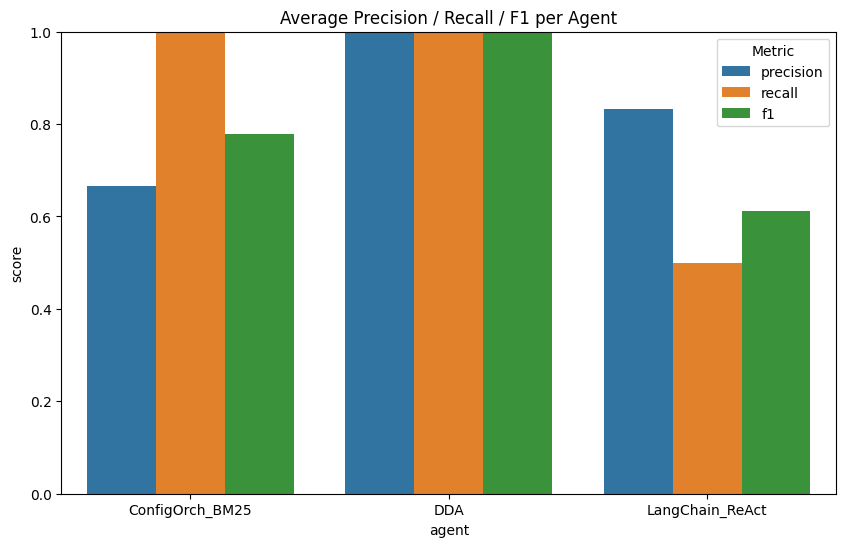

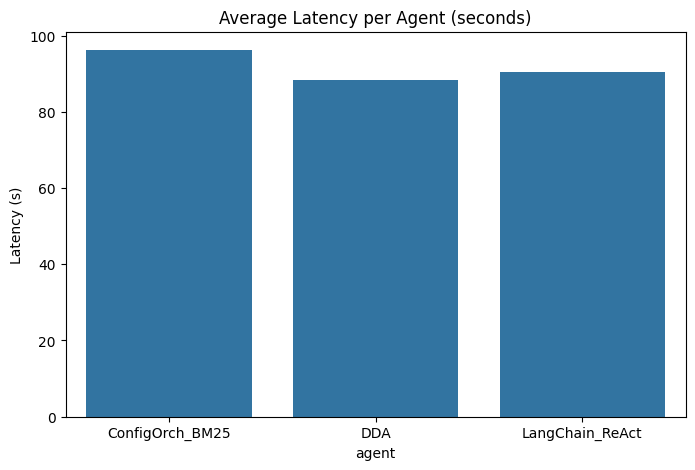

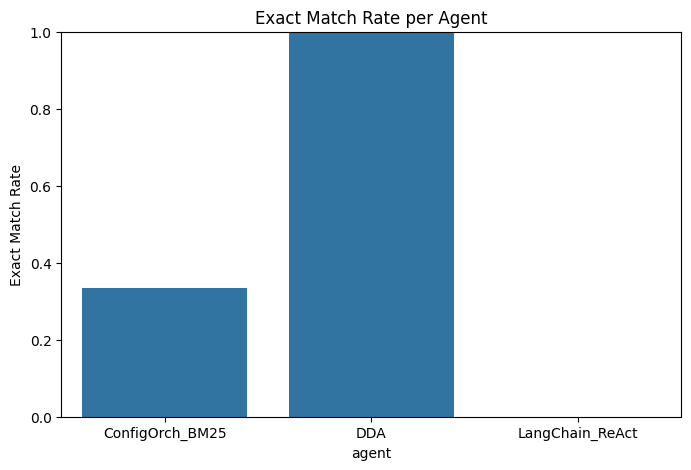

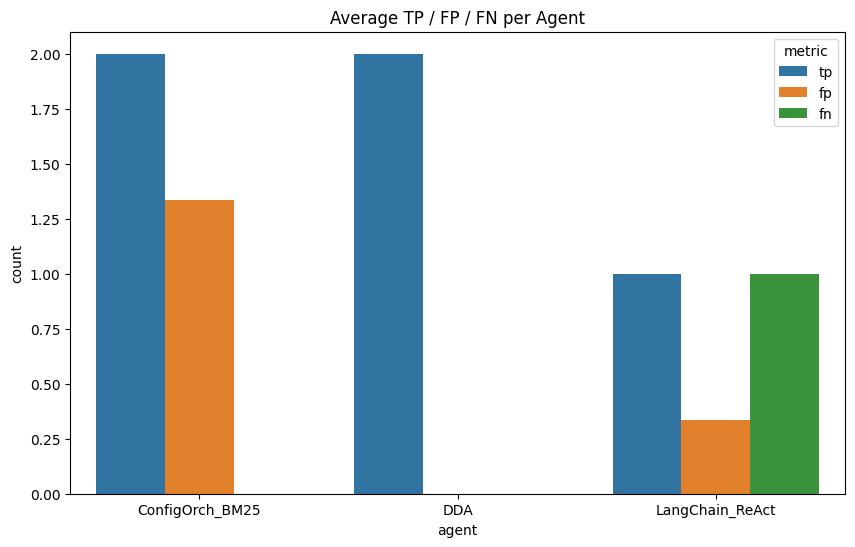

In [37]:
df = plot_benchmark_summary(quick_results)


## **Performance Analysis**

**DataFlow Agent (DDA) emerges as the clear winner** — achieving perfect scores across all three queries by calling exactly the right tools every time. It also proves to be the most efficient, with an least latency. 

**ConfigOrch_BM25 (ToolRAG agent)** demonstrates perfect recall, never missing a required tool. However, this comes at the cost of poor precision (0.556) due to significant **over-fetching** — the BM25 retrieval mechanism casts too wide a net, returning many irrelevant tools alongside the necessary ones. With 0/3 exact matches, the agent consistently includes the correct tools but fails to deliver a precise set without excess noise.

**LangGraph_ReAct (ReAct agent)** exhibits the opposite problem: decent precision (0.833) shows it rarely calls wrong tools, but poor recall (0.5) means it misses half the required tools because the small language model (SLM), MedGemma-1.5-4B, orchestrating the agent tends to get stuck in loops, repeatedly calling the same tool. This behavior is circumvented by the loop-detection and early-stop mechanisms in the LangGraph execution (using MedGemma-4B), which halt after just 1-2 tool calls when the task demands more. Like ToolRAG, it achieves 0/3 exact matches for the same underlying reason — incomplete tool execution.


In [33]:
# Full benchmark run (all 10 queries)
full_results = await run_benchmark(ONCOLOGY_BENCHMARK, agents_to_test)
summary = print_summary(full_results)

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



  BENCHMARK: 10 queries x 3 agents

[E1] BMI classification from vitals -> 'bmi_category'
       Expected: ['record_vitals', 'calculate_bmi_category']
    DDA... 
[DDA] Patient P001 has heart rate 82 bpm. Record their vitals and classify their BMI c
[Step 1] Variable Extraction


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


    3 populated: ['heart_rate', 'patient_id', 'theatre_block_hrs']
    28 source keys (leaf inputs): 28
    29 total available
[Step 2] Goal Key Identification
    Target: 'bmi_category'
[Step 3] DataFlow Graph Resolution
    Plan (3 tools): ['record_vitals', 'register_patient_case', 'calculate_bmi_category']
[Step 4] Execution
    [1/3] record_vitals


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

    1 populated: ['patient_id']
    28 source keys (leaf inputs): 28
    29 total available
[Step 2] Goal Key Identification
    Target: 'chemotherapy_response_index'
[Step 3] DataFlow Graph Resolution
  NULL PLAN: no path to 'chemotherapy_response_index'
NULL-OK P=1.00 R=1.00 F1=1.00 | 0 tools | 43.0s
    ConfigOrch_BM25... 

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:1 for op

NULL-MISS P=0.00 R=1.00 F1=0.00 | 3 tools | 92.1s
    LangChain_ReAct... 

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


NULL-MISS P=0.00 R=1.00 F1=0.00 | 1 tools | 112.7s

  BENCHMARK SUMMARY
Agent                            Prec    Rec     F1  Exact     Lat
-----------------------------------------------------------------
  DDA                           1.000  0.925  0.952   8/10   89.9s
  ConfigOrch_BM25               0.617  0.842  0.623   1/10  117.9s
  LangChain_ReAct               0.850  0.575  0.569   2/10   99.7s


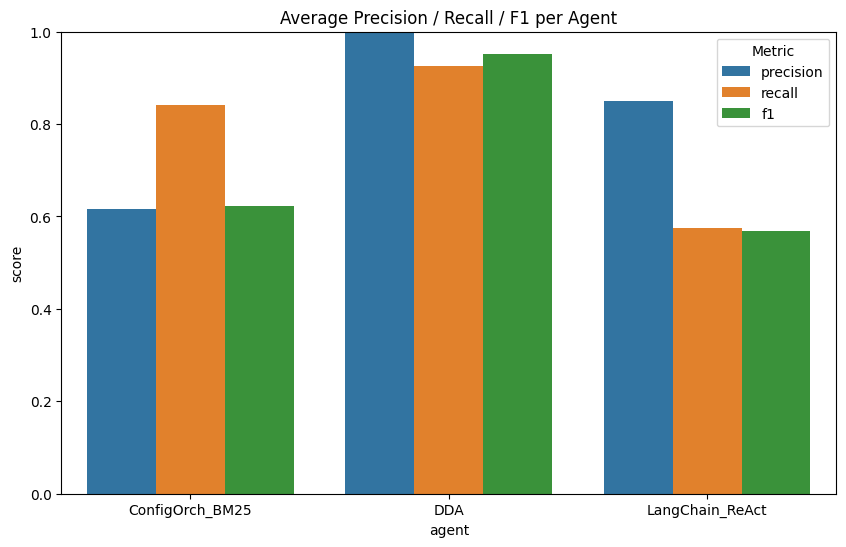

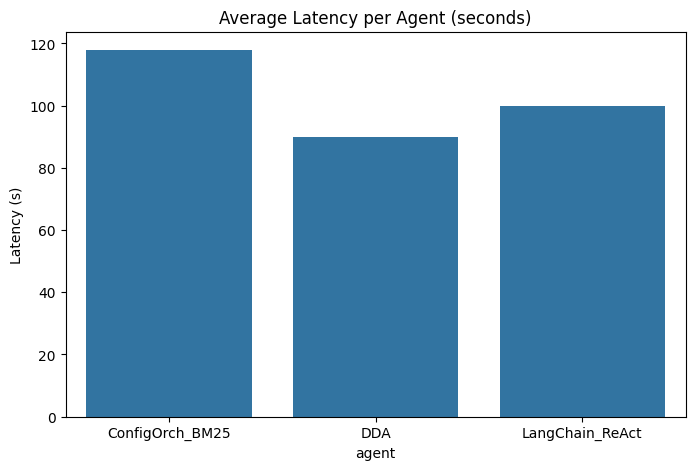

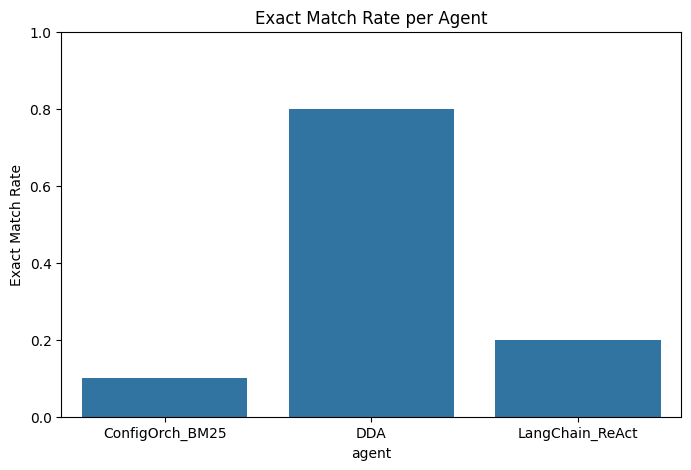

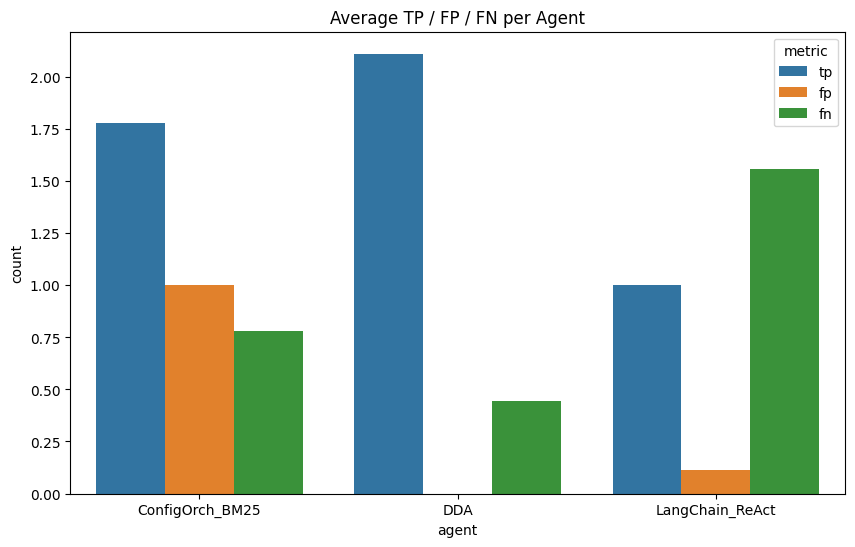

In [38]:
df = plot_benchmark_summary(full_results)

---
## **Part V: DDA End-to-End Demonstrations**

In [ ]:
# Demo 1: Full surgical pathway (6 tools, 5 phases)
print('='*60)
print('DEMO 1: Full Surgical Readiness Assessment')
print('='*60)

r1 = await dda_agent.run(
    user_query=(
        'Patient P001 needs surgical readiness assessment. '
        'She has heart rate 82 bpm. Run ECG for 30 seconds, '
        'get echocardiogram, and perform 3-core biopsy at coordinates [125,80,45] '
        'to determine if she is fit for surgery.'
    ),
    target_key='surgical_readiness_status'
)
print(f'\nPlan: {r1["execution_plan"]}')
print(f'Executed: {r1["tools_executed"]}')
print(f'Status: {r1["status"]}')
print(f'Latency: {r1["latency_s"]}s')
print(f'\nResponse:\n{r1["response"]}')

In [ ]:
from IPython.display import display, Markdown

display(Markdown(r1["response"]))

<unused94>thought
Here's a thinking process to arrive at the structured response:

1.  **Understand the Goal:** The user wants a structured response to a clinical instruction for Patient P001 regarding surgical readiness assessment. The instruction involves specific actions: HR check, ECG, echocardiogram, and a 3-core biopsy. The user also provides some clinical data (needle biopsy code, histopathology results, ECG analysis).

2.  **Identify the Core Task:** The main task is to process the clinical instruction and generate a structured response that reflects the steps involved, incorporates the provided data, and potentially adds necessary context or considerations.

3.  **Break Down the Instruction:**
    *   **Patient:** P001
    *   **Objective:** Surgical readiness assessment.
    *   **Action 1:** Check heart rate (HR) at 82 bpm.
    *   **Action 2:** Run ECG for 30 seconds.
    *   **Action 3:** Perform echocardiogram.
    *   **Action 4:** Perform 3-core biopsy at coordinates [125, 80, 45].
    *   **Purpose of Biopsy:** Determine surgical fitness.

4.  **Incorporate Provided Clinical Data:**
    *   `perform_needle_biopsy: PATH-SAMPLE-96390`: This is the code for the biopsy procedure. It's relevant context.
    *   `analyze_histopathology: {'malignancy_grade': 2, 'cell_morphology': 'adenocarcinoma'}`: This is crucial information. A malignancy grade of 2 (likely moderately differentiated) and adenocarcinoma histology are significant findings that directly impact surgical fitness.
    *   `perform_ecg_analysis: Sinus`: This is the result of the ECG. "Sinus" is a normal finding, suggesting no significant arrhythmias at the time of the ECG.

5.  **Structure the Response:** A structured response should be clear, logical, and easy to follow. A good structure would be:
    *   **Patient Identification:** Start by clearly stating the patient.
    *   **Objective:** Reiterate the goal (surgical readiness assessment).
    *   **Assessment Steps:** Detail the actions requested in the instruction, incorporating the data where relevant.
    *   **Key Findings/Considerations:** Summarize the most important information derived from the clinical data,

In [ ]:
# Demo 2: Recovery trend (2 tools, Phase 9)
print('='*60)
print('DEMO 2: Post-operative Recovery Trend')
print('='*60)

r2 = await dda_agent.run(
    'Sync 7 days of wearable data for patient P001 and analyze their recovery against a 5000 step target.',
    target_key='recovery_trend'
)
print(f'Plan: {r2["execution_plan"]}')
print(f'Response: {r2["response"]}')

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


DEMO 2: Post-operative Recovery Trend

[DDA] Sync 7 days of wearable data for patient P001 and analyze their recovery against
[Step 1] Variable Extraction


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


    4 populated: ['ecg_duration_sec', 'monitoring_days', 'patient_id', 'recovery_target_steps']
    28 source keys (leaf inputs): 28
    29 total available
[Step 2] Goal Key Identification
    Target: 'recovery_trend'
[Step 3] DataFlow Graph Resolution
    Plan (2 tools): ['sync_patient_wearable_data', 'analyze_recovery_trend']
[Step 4] Execution
    [1/2] sync_patient_wearable_data


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


        OK: [2163, 1869, 1885, 1443, 2380, 1206, 2280]
    [2/2] analyze_recovery_trend


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


        OK: Critical
[Step 5] Synthesis
DDA complete in 90.79s | Executed: ['sync_patient_wearable_data', 'analyze_recovery_trend']
Plan: ['sync_patient_wearable_data', 'analyze_recovery_trend']
Response: <unused94>thought
Here's a thinking process to arrive at the structured response:

1.  **Understand the Goal:** The user wants to analyze the recovery trend of patient P001 based on 7 days of wearable data, specifically focusing on their steps against a 5000-step target. The user emphasizes "precision oncology AI assistant" and "structured response."

2.  **Identify Key Information:**
    *   Pati


In [ ]:
from IPython.display import display, Markdown

display(Markdown(r2["response"]))

<unused94>thought
Here's a thinking process to arrive at the structured response:

1.  **Understand the Goal:** The user wants to analyze the recovery trend of patient P001 based on 7 days of wearable data, specifically focusing on their steps against a 5000-step target. The user emphasizes "precision oncology AI assistant" and "structured response."

2.  **Identify Key Information:**
    *   Patient ID: P001
    *   Data Source: Wearable data
    *   Data Duration: 7 days
    *   Target Metric: Steps
    *   Target Value: 5000 steps
    *   Analysis Focus: Recovery trend
    *   Output Format: Structured response

3.  **Structure the Response:** A structured response needs clear sections. Logical sections would be:
    *   **Objective:** State the goal clearly.
    *   **Data:** Describe the data used.
    *   **Analysis:** Detail the steps taken to analyze the data.
    *   **Results:** Present the findings.
    *   **Interpretation/Conclusion:** Explain what the results mean in the context of the patient's recovery.
    *   **Recommendations (Optional but helpful):** Suggest next steps or considerations.

4.  **Flesh out each section:**

    *   **Objective:** Rephrase the user's question into a formal objective. "Analyze the recovery trend of patient P001 based on 7 days of wearable step data, comparing daily steps against a 5000-step target."

    *   **Data:** List the provided data points.
        *   Wearable data: `[2163, 1869, 1885, 1443, 2380, 1206, 2280]`
        *   Target: 5000 steps

    *   **Analysis:** Describe the process.
        *   **Data Preparation:** Mention the data is already provided (a list of daily step counts).
        *   **Target Calculation:** Calculate the target value (5000 steps).
        *   **Step Comparison:** Explain how to compare each day's steps to the target.
        *   **Trend Identification:** Describe how to look for patterns (improvement, decline, plateau) over the 7 days.

In [ ]:
# Demo 3: NULL PATH -- registry gap detection
print('='*60)
print('DEMO 3: NULL PATH -- Registry Gap Detection')
print('='*60)

r3 = await dda_agent.run(
    'Calculate the chemotherapy response index for patient P001.',
    target_key='chemotherapy_response_index'
)
print(f'Status: {r3["status"]}')
print(f'Plan: {r3["execution_plan"]}')
print(f'\nResponse: {r3["response"]}')
print('\nThis is the DDA advantage: explicit null rather than hallucinated tool calls.')

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


DEMO 3: NULL PATH -- Registry Gap Detection

[DDA] Calculate the chemotherapy response index for patient P001.
[Step 1] Variable Extraction
    1 populated: ['patient_id']
    28 source keys (leaf inputs): 28
    29 total available
[Step 2] Goal Key Identification
    Target: 'chemotherapy_response_index'
[Step 3] DataFlow Graph Resolution
  NULL PLAN: no path to 'chemotherapy_response_index'
Status: null_plan
Plan: None

Response: Registry gap: no execution path to produce 'chemotherapy_response_index' from available context ['age_input', 'allergy_list', 'biopsy_coordinates', 'biopsy_sample_count', 'body_region', 'contrast_flag', 'crp_level', 'ecg_duration_sec', 'heart_rate', 'iv_rate_ml_hr', 'mobility_score', 'monitoring_days', 'oncology_department', 'pain_scale', 'panel_type', 'patient_id', 'patient_name_input', 'record_version', 'recovery_target_steps', 'referral_priority', 'robotic_trajectory', 'spo2_pct', 'stain_type', 'surgeon_id', 'surgery_duration_mins', 'theatre_block_hrs', '

In [ ]:
# Demo 4: Architecture comparison on same query
print('='*60)
print('DEMO 4: DDA vs ConfigOrch -- Same Query')
print('='*60)

query = 'Patient P001 weighs 68 kg, surgery lasts 180 minutes. Calculate anesthesia protocol.'

print('\n-- DDA --')
dda_r = await dda_agent.run(query, target_key='anesthesia_protocol')
print(f'  Resolved plan: {dda_r["execution_plan"]}')
print(f'  Executed:      {dda_r["tools_executed"]}')
print(f'  Latency:       {dda_r["latency_s"]}s')

print('\n-- ConfigurableOrchestrator --')
conf_r = await config_orch.run(query)
print(f'  Retrieved: {conf_r["tools_executed"]}')
print(f'  Latency:   {conf_r["latency_s"]}s')
print('\nDDA selects exactly what is needed. ConfigOrch retrieves top-K (may include irrelevant tools).')

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


DEMO 4: DDA vs ConfigOrch -- Same Query

-- DDA --

[DDA] Patient P001 weighs 68 kg, surgery lasts 180 minutes. Calculate anesthesia proto
[Step 1] Variable Extraction


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


    4 populated: ['anesthesia_protocol', 'patient_id', 'surgery_duration_mins', 'weight_kg']
    28 source keys (leaf inputs): 28
    30 total available
[Step 2] Goal Key Identification
    Target: 'anesthesia_protocol'
[Step 3] DataFlow Graph Resolution
    Plan (1 tools): ['calculate_anesthesia_protocol']
[Step 4] Execution
    [1/1] calculate_anesthesia_protocol


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


        OK: [188.0, 226.0]
[Step 5] Synthesis


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


DDA complete in 47.08s | Executed: ['calculate_anesthesia_protocol']
  Resolved plan: ['calculate_anesthesia_protocol']
  Executed:      ['calculate_anesthesia_protocol']
  Latency:       47.08s

-- ConfigurableOrchestrator --


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:1 for op

  Retrieved: ['calculate_anesthesia_protocol']
  Latency:   117.46s

DDA selects exactly what is needed. ConfigOrch retrieves top-K (may include irrelevant tools).


---
## Part VI: Analysis & Discussion

### Architectural Comparison

| Property | DDA | ConfigOrch | LangChain ReAct |
|---|---|---|---|
| **Tool selection** | Backward graph traversal | BM25 top-K similarity | LLM Thought->Action |
| **Null path** | Explicit `null_plan` status | Never -- may select wrong tools | Never -- may hallucinate |
| **LLM calls** | 2 (extraction + goal) | 2-3 (plan + extraction + synth) | N (per tool call) |
| **Determinism** | Yes -- same query = same plan | No (BM25+LLM stochastic) | No (LLM-driven) |
| **Over-selection** | Never (exact path only) | Possible (top-K may include extras) | Possible |
| **Registry gap** | Explicitly detected | Silently degrades | Silently degrades |

### When to Use Each

**Use DDA when:**
- Tool dependencies are explicit and well-registered (clinical, legal, financial pipelines)
- Null results must be explicit (safety-critical systems)
- Minimal LLM calls per workflow is a constraint
- Debuggability and traceability are required

**Use ConfigOrch when:**
- Tool schemas are incomplete or inconsistently defined
- Creative tool combinations not captured in the schema are needed
- Exploratory open-ended agent behavior is desired

### Future Work
- **Multi-goal resolution**: plans that satisfy multiple target keys simultaneously
- **Branch planning**: when output is uncertain (e.g. `lesion_detected: False`), branch plan accordingly
- **Gap suggestions**: when null path detected, suggest which tool signature would close the gap
- **Parallel execution**: tools with no data dependencies can run in parallel within a resolved plan